# Voter Network and Hypernetwork Modles (Chapter 3)

## Jason LaRuez, Brendan Rooney
---
This notebook contains the code for generating many of the Chapter 3 (voter models on graphs and hypergraphs) figures from the dissertation "Topological Tools for the Analysis of Complex Networks and Higher-Order Networks". We apply zigzag persistence to a network and hypernetwork voter model with double-edge swapping mechanisms.

Disclaimer: much of code used for the final plots was created using generative AI

In [1]:
# Mounting to google drive. Forced remount allows you to access newly uploaded/updated files and
# folders in the googe drive. If files are stored locally or elsewhere, can comment out
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

!pip install dionysus==2.0.10
import dionysus as d

!pip install rbloom
from rbloom import Bloom

import math
import networkx as nx # Network structures
import numpy as np # Numpy arrays and operations
import random # Random sampling for network models
from itertools import combinations, product # For getting different simplices and all combinations of lists

import matplotlib.pyplot as plt # Plotting
import time # Timing simulations
from tqdm.notebook import trange, tqdm # Allows for real-time progress bar of simulations

import gc # Memory management
import pickle # Takes environment variables and saves them as is
import gzip # Allows for compression of saved files
from joblib import Parallel, delayed # Parallelization functions
import multiprocessing # Get number of cpu cores
import os
import sys

import collections
import matplotlib as mpl
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path

plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         13,
    'axes.labelsize':    14,
    'axes.titlesize':    14,
    'legend.fontsize':   13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        150,
    'axes.grid':         False,
    'grid.linewidth':    0.4
})

Mounted at /content/drive


In [3]:
sys.path.append('/content/drive/MyDrive/Colab Notebooks')
from VoterModels import *

## Graph rewire-to-random model with node-swapping

In [ ]:
N = [2000]; M = [2000,4000,6000,8000,10000]; rhos = [0.1,0.2,0.3,0.4]; alphas = np.linspace(0,1,21)[:-1]; iterations = range(1,101);
params = [N, M, rhos, alphas, iterations]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(PC_G_RewireRandom)(param) for param in tqdm(params))

## Rewire-to-Same model on graphs

In [ ]:
N = [2000]; M = [2000,4000,6000,8000,10000]; rhos = [0.1,0.2,0.3,0.4]; alphas = np.linspace(0,1,21)[:-1]; iterations = range(1,101);
params = [N, M, rhos, alphas, iterations]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(PC_G_RewireSame)(param) for param in tqdm(params))

  0%|          | 0/40000 [00:00<?, ?it/s]

## Triangle-rewire on graphs

In [ ]:
N = [5000]; M = [10000]; rhos = [0.2,0.4]; alphas = np.linspace(0,1,21); gammas = np.linspace(0,1,21); iterations = range(1,6);
params = [N, M, rhos, alphas, iterations]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(PC_G_RewireTriangleSame)(param) for param in tqdm(params))

## Hypergraph rewire-to-random model with node-swapping:

At each timestep a discordant hyperedge (not all nodes have same opinion) is selected uniformly at random. With probability $\alpha$ the edge is rewired by randomly selecting a second hyperedge, and two nodes from those hyperedges are randomly swapped. Otherwise, with probability $(1-\alpha)$ social influence occurs by either majority voting or proportional voting. In majority voting each node in the edge adopts the opinion of the majority. In proportional voting an opinion is adopted by the entire edge proportional to the number of nodes in that edge initially holding said opinion.

In [ ]:
N = 1000; size = 3;
E = [sorted([(v+i) % N for i in range(K)]) for K in range(2,size+1) for v in range(N)]
#E = [sorted([(v+i) % N for i in range(size)]) for v in range(N) for size in range(2, K+1)]
H = {i: e for i, e in enumerate(E)}

alpha = .2
rho = 0.2;
Proportions, DiscordantCounts, H = HG_RewireRandom_Voter(H, alpha, rho, voting = 'Proportional')

In [ ]:
N = [5000]; M = [10000]; K = [3,4]; rhos = [0.4]; alphas = np.linspace(0,1,21); gammas = np.linspace(0,1,21); voting_rules = ['Proportional','Majority']; iterations =[4,5];
params = [N, M, K, rhos, alphas, gammas, voting_rules, iterations]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = 24

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(PC_HG_RewireTriangleSame)(param) for param in tqdm(params))

## Voter model on simplicial Watts-Strogatz hypergraphs

In [ ]:
N = [500]; K = [3,4]; rhos = [0.4]; alphas = np.linspace(0,1,11)[1:]; gammas = np.linspace(0,1,11); voting=['Majority']; iterations = range(1,6); P = [0.5]
params = [N, K, rhos, alphas, gammas, voting, iterations, P]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(PC_Simplicial_WS)(param) for param in tqdm(params))

Loading graph trajectories...
Loaded: α=0.0, γ=0.2
Loaded: α=0.0, γ=0.4
Loaded: α=0.0, γ=0.6
Loaded: α=0.0, γ=0.8
Loaded: α=0.0, γ=1.0
Loaded: α=0.2, γ=0.2
Loaded: α=0.2, γ=0.4
Loaded: α=0.2, γ=0.6
Loaded: α=0.2, γ=0.8
Loaded: α=0.2, γ=1.0
Loaded: α=0.4, γ=0.2
Loaded: α=0.4, γ=0.4
Loaded: α=0.4, γ=0.6
Loaded: α=0.4, γ=0.8
Loaded: α=0.4, γ=1.0
Loaded: α=0.6, γ=0.2
Loaded: α=0.6, γ=0.4
Loaded: α=0.6, γ=0.6
Loaded: α=0.6, γ=0.8
Loaded: α=0.6, γ=1.0
Loaded: α=0.8, γ=0.2
Loaded: α=0.8, γ=0.4
Loaded: α=0.8, γ=0.6
Loaded: α=0.8, γ=0.8
Loaded: α=0.8, γ=1.0

Successfully loaded 25 trajectories
Saved: graph_arch_plot_rho0.4.png


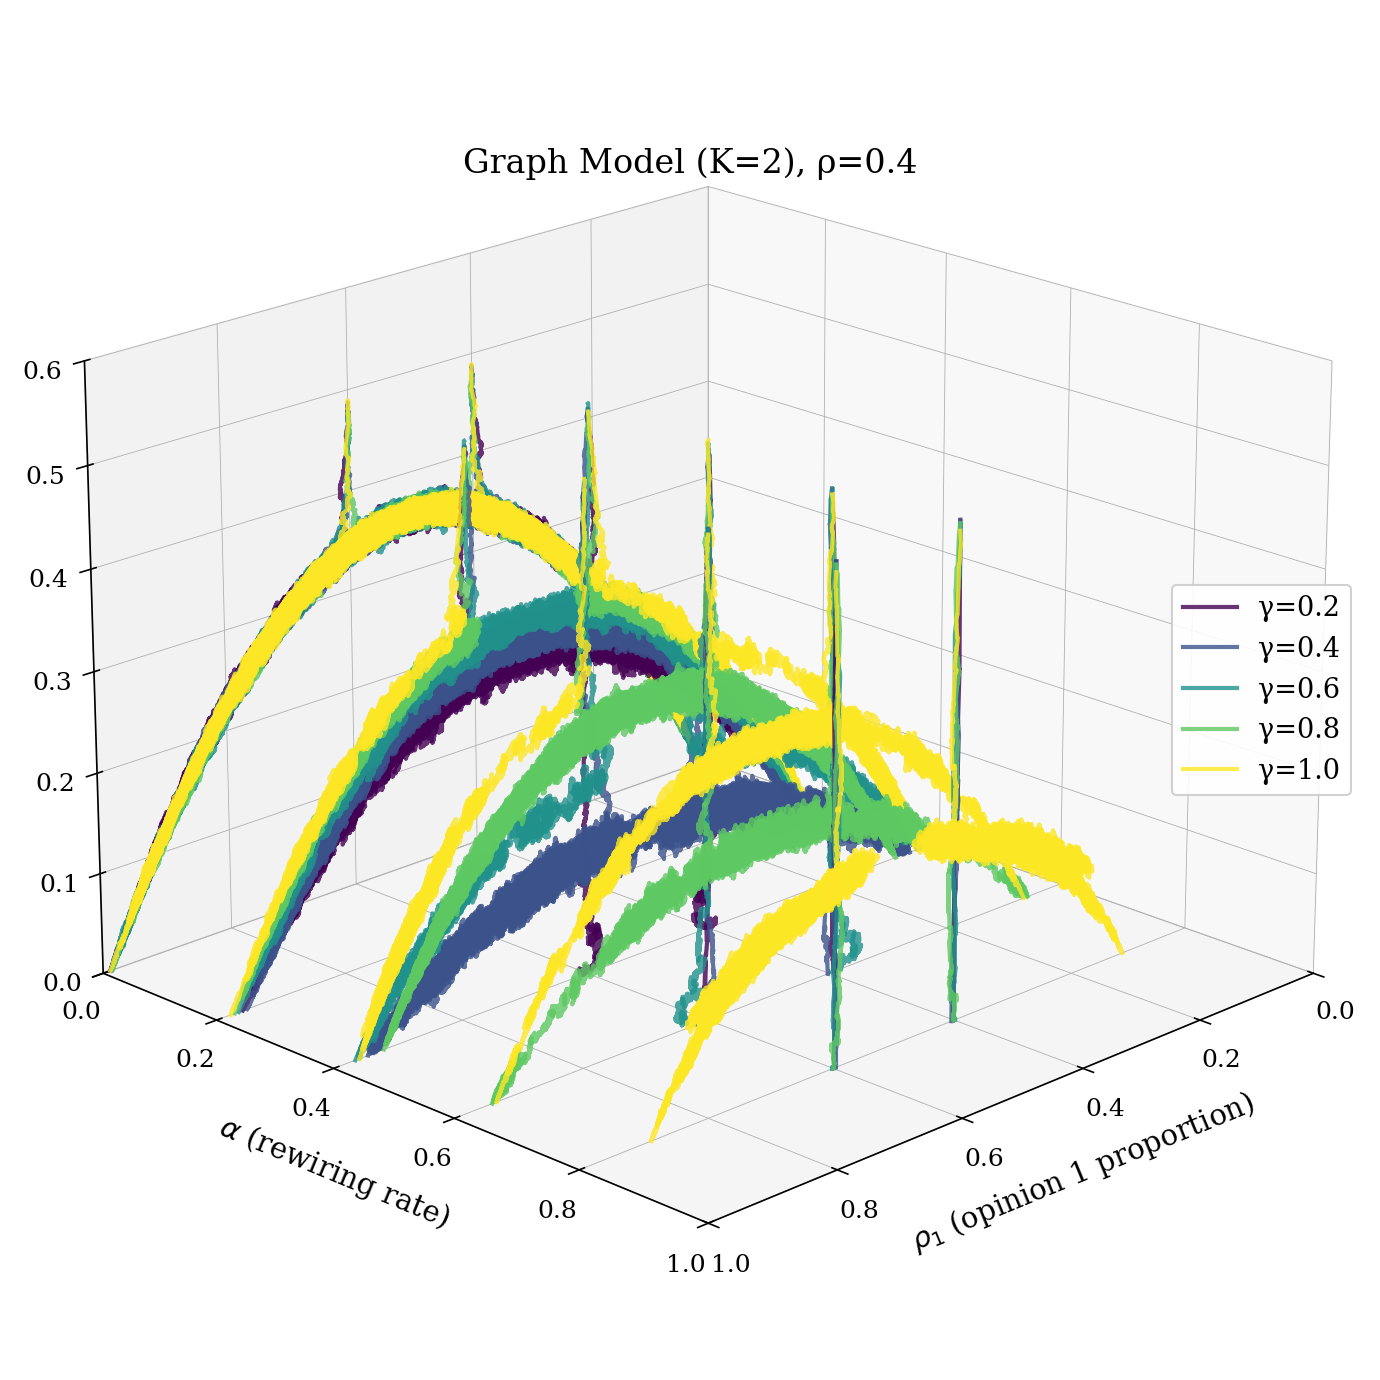

In [6]:
mpl.rcParams['agg.path.chunksize'] = 10000
mpl.rcParams['path.simplify'] = True
mpl.rcParams['path.simplify_threshold'] = 1.0

# Parameters
N = 5000
M = 10000
rho = 0.4
gamma_values = [0.2, 0.4, 0.6000000000000001, 0.8, 1.0]
alpha_values = [0.0, 0.2, 0.4, 0.6000000000000001, 0.8]
iteration = 1  # Load first iteration

base_path = '/content/drive/Othercomputers/My Computer (1)/Dissertation/VoterData/G/Triangle/'

# Load all trajectories into a dictionary
print("Loading graph trajectories...")
graph_data = {}

for alpha in alpha_values:
    for gamma in gamma_values:
        Proportions, DiscordantCounts = load_single_trajectory_arch(
            N, M, rho, alpha, gamma, iteration, base_path)

        if Proportions is not None:
            key = (alpha, gamma)
            graph_data[key] = {
                'Proportions': Proportions,
                'DiscordantCounts': DiscordantCounts,
                'params': {'n': N, 'm': M, 'rho': rho, 'alpha': alpha, 'gamma': gamma}}
            print(f"Loaded: α={alpha:.1f}, γ={gamma:.1f}")

print(f"\nSuccessfully loaded {len(graph_data)} trajectories")

# Generate the plot
fig, ax = create_graph_arch_figure(graph_data, rho, alpha_values, gamma_values, save_path='graph_arch_plot_rho0.4.png')
plt.show()

In [ ]:
CMAP = 'plasma'
n, m       = 5000, 10000
rhos       = [0.1, 0.2, 0.3, 0.4]
alphas     = np.linspace(0, 1, 21)
gammas     = np.linspace(0, 1, 21)
iterations = range(1, 11)
na, ng     = len(alphas), len(gammas)

TICK_IDX = np.arange(0, na, 4)
XLABELS  = [f'${alphas[i]:.1f}$' for i in TICK_IDX]
YLABELS  = [f'${gammas[i]:.1f}$' for i in TICK_IDX]

base_path = '/content/drive/Othercomputers/My Computer (1)/Dissertation/VoterData/G/Triangle/'
base_dir = Path(base_path)

# =============================================================================
# PARALLEL LOAD
# =============================================================================

er_sums   = {rho: np.zeros((ng, na)) for rho in rhos}
er_counts = {rho: np.zeros((ng, na)) for rho in rhos}

er_jobs = [
    (rho, ai, gi, it) for rho in rhos for ai  in range(na) for gi  in range(ng) for it  in iterations]

print('Loading ER terminal proportions...')
er_results = Parallel(n_jobs=-1, backend='loky')(
    delayed(load_er_proportion)(base_dir, n, m, alphas, gammas, rho, ai, gi, it)
    for rho, ai, gi, it in tqdm(er_jobs, desc='Loading'))

for out in tqdm(er_results, desc='Accumulating'):
    if out is None:
        continue
    rho, ai, gi, minority = out
    er_sums[rho][gi, ai]   += minority
    er_counts[rho][gi, ai] += 1

# =============================================================================
# MEANS
# =============================================================================

er_means = {}
for rho in rhos:
    c = er_counts[rho]
    with np.errstate(invalid='ignore', divide='ignore'):
        er_means[rho] = np.where(c > 0, er_sums[rho] / c, np.nan)

Loading ER terminal proportions...


Loading:   0%|          | 0/17640 [00:00<?, ?it/s]

In [ ]:
# =============================================================================
# PLOT
# =============================================================================

plot_er_terminal(er_means, n, m, rhos, TICK_IDX, XLABELS, YLABELS,
    save_path=os.path.join(base_dir, f'terminal_minority_ER_n{n}_m{m}.png'))

In [ ]:
# =============================================================================
# CONFIGURATION
# =============================================================================

BASE_G = ('/content/drive/Othercomputers/My Computer (1)/Dissertation/'
          'VoterData/G/Triangle/')
PROC_G = os.path.join(BASE_G, 'proc')
os.makedirs(PROC_G, exist_ok=True)

n          = 5000
m          = 10000
alphas     = np.linspace(0, 1, 21)
gammas     = np.linspace(0, 1, 21)
iterations = range(1, 11)
rhos       = [0.1, 0.2, 0.3, 0.4]
na, ng     = len(alphas), len(gammas)
fields_g   = ['b0', 'b1', 'b2', 'euler', 'N0', 'N1', 'N2', 'N3']

alpha_labels = [f'{a:.2f}' for a in alphas]
gamma_labels = [f'{g:.2f}' for g in gammas]
tick_interval = 5


# =============================================================================
# PART I: PARALLEL COMPUTE AND SAVE
# =============================================================================
results = Parallel(n_jobs=-1, backend='loky')(
    delayed(compute_and_save_graph)(n, m, rho, alpha, gamma, iteration, BASE_G, PROC_G)
    for rho in rhos for it in iterations)

In [ ]:
# =============================================================================
# PART II: PARALLEL LOAD AND ACCUMULATE
# =============================================================================

all_jobs_g = [
    (rho, ai, gi, it)
    for rho in rhos
    for ai, _ in enumerate(alphas)
    for gi, _ in enumerate(gammas)
    for it in iterations
]

sums_g   = {rho: {fld: np.zeros((ng, na)) for fld in fields_g}
            for rho in rhos}
counts_g = {rho: np.zeros((ng, na)) for rho in rhos}

print('Loading graph TDA results...')
results_g = Parallel(n_jobs=-1, backend='loky')(
    delayed(load_one_graph)(rho, alphas, gammas, ai, gi, it)
    for rho, ai, gi, it in tqdm(all_jobs_g, desc='Submitting'))

for out in tqdm(results_g, desc='Accumulating'):
    if out is None:
        continue
    rho, ai, gi, res = out
    for fld in fields_g:
        sums_g[rho][fld][gi, ai] += res[fld]
    counts_g[rho][gi, ai] += 1


# ── means and derived quantities ──────────────────────────────────────────────
means_g = {rho: {fld: gmean(counts_g, sums_g, rho, fld) for fld in fields_g}
           for rho in rhos}

derived_g = {}
for rho in rhos:
    means = means_g[rho]
    b0, b1, b2       = means['b0'], means['b1'], means['b2']
    N0, N1, N2, N3   = means['N0'], means['N1'], means['N2'], means['N3']
    euler            = means['euler']

    with np.errstate(invalid='ignore', divide='ignore'):
        tb0   = np.where(N0 > 0, b0 / N0, np.nan)
        tb1   = np.where(N1 > 0, b1 / N1, np.nan)
        tb2   = np.where(N2 > 0, b2 / N2, np.nan)
        CR1   = N1 - N0 + b0
        CR1b1 = CR1 - b1
        g1    = np.where(N2 > 0, CR1b1 / N2, np.nan)
        CR2   = N2 - CR1 + b1
        CR2b2 = CR2 - b2
        g2    = np.where(N3 > 0, CR2b2 / N3, np.nan)

    derived_g[rho] = {
        r'$\beta_0$ (components)':                          b0,
        r'$\tilde{\beta}_0=\beta_0/N$':                  tb0,
        r'$\beta_1$ (tunnels)':                          b1,
        r'$\tilde{\beta}_1=\beta_1/N_1$':                  tb1,
        r'$\beta_2$ (voids)':                          b2,
        r'$\tilde{\beta}_2=\beta_2/N_2$':                  tb2,
        r'$\chi$ (Euler characteristic)':                             euler,
        r'$N_1$ (edges)':                              N1,
        r'$N_2$ (triangles)':                              N2,
        r'$N_3$ (tetrahedra)':                              N3,
        r'$\mathcal{CR}_1 - \beta_1$ (filled tunnels)':        CR1b1,
        r'$\gamma_1$ (1-filling efficiency)':                         g1,
        r'$\mathcal{CR}_2 - \beta_2$ (filled voids)':        CR2b2,
        r'$\gamma_2$ (2-filling efficiency)':                         g2,
    }

Loading graph TDA results...


Submitting:   0%|          | 0/17640 [00:00<?, ?it/s]

Accumulating:   0%|          | 0/17640 [00:00<?, ?it/s]

Saved: /content/drive/Othercomputers/My Computer (1)/Dissertation/VoterData/G/Triangle/heatmap_styled_n5000_m10000_rho0_4.png


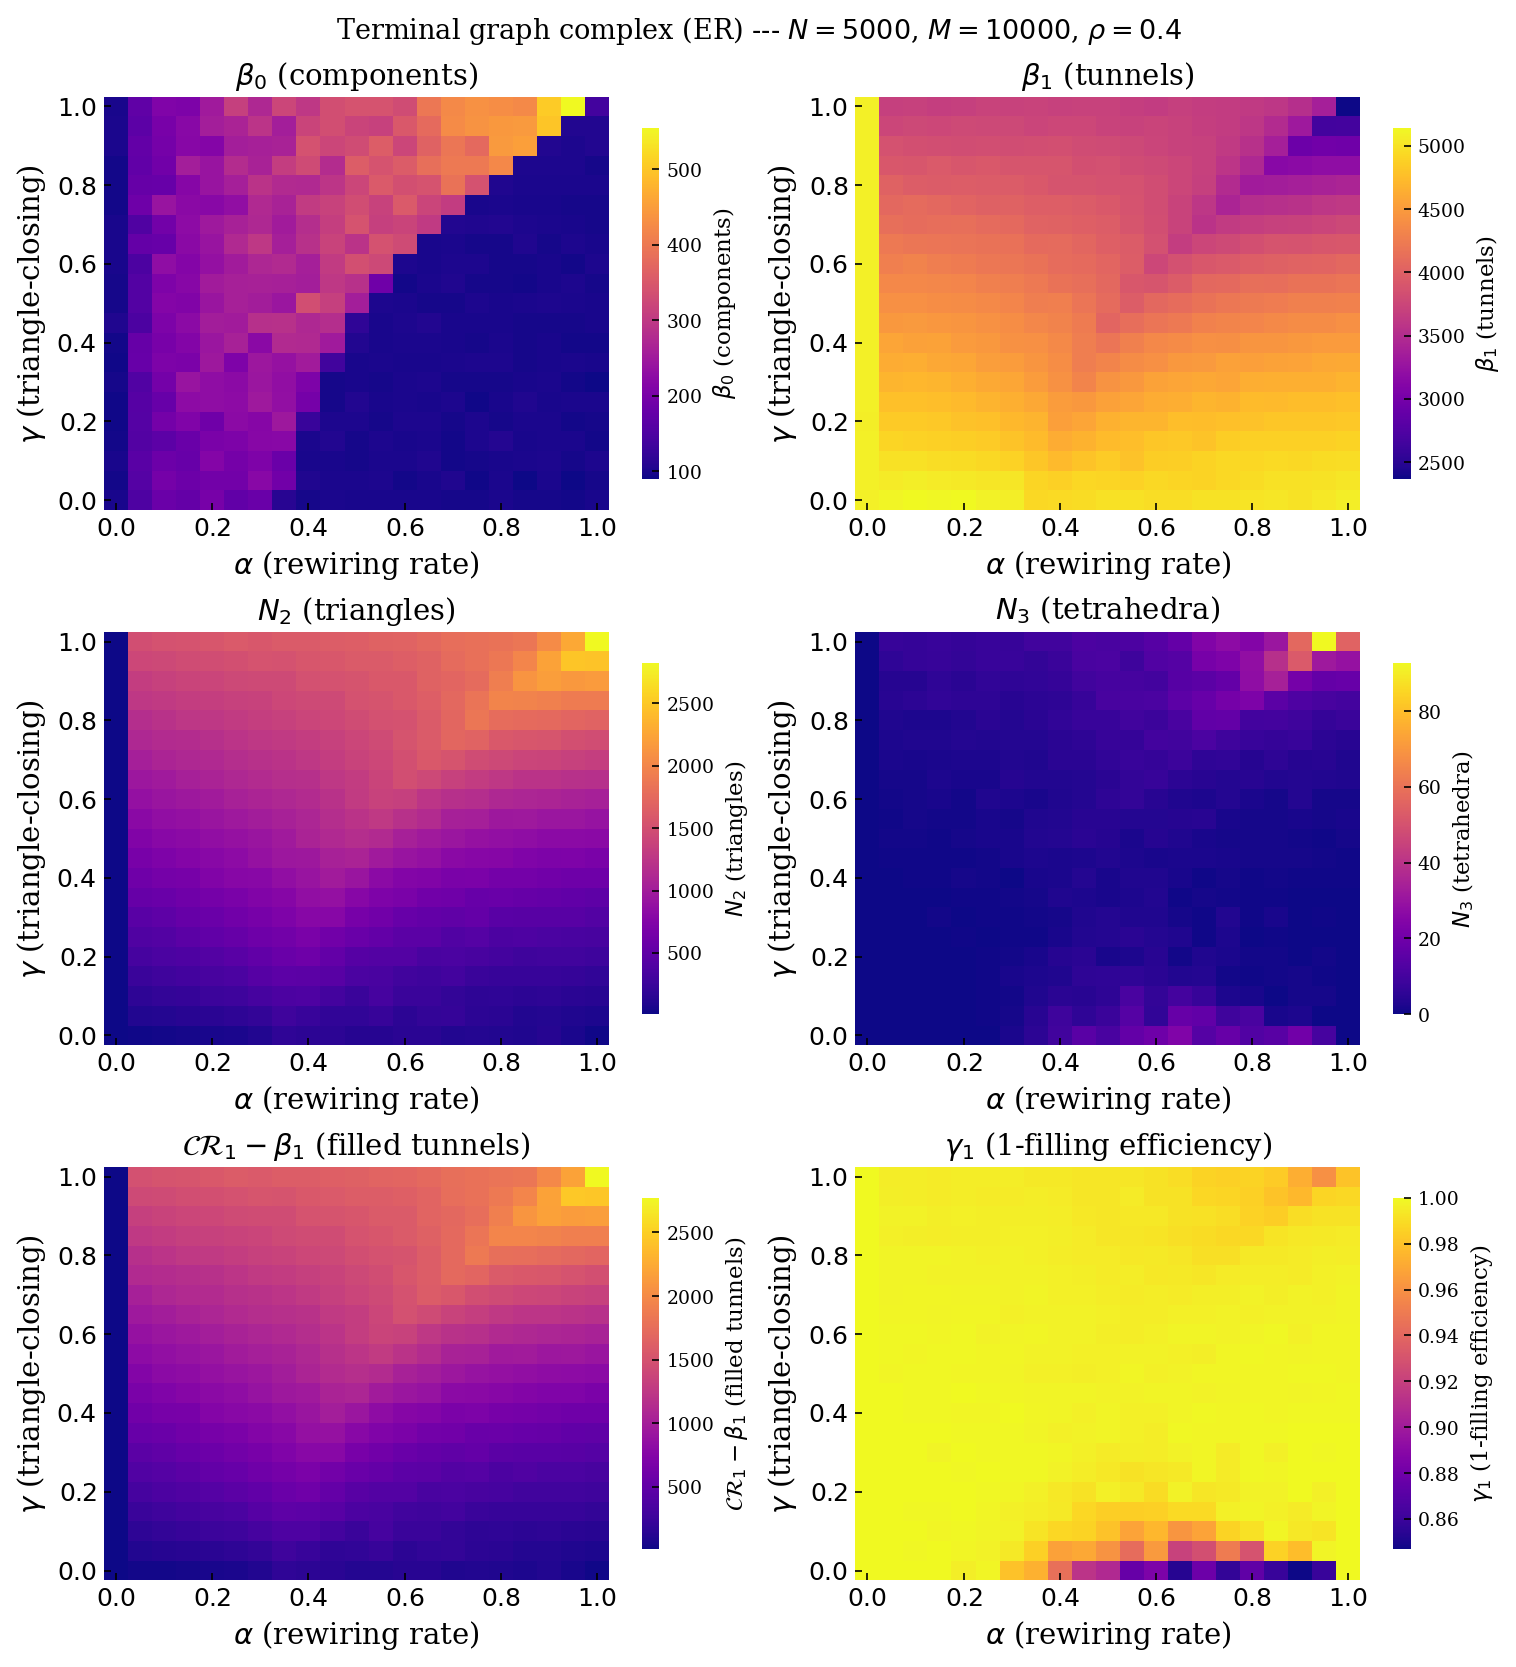

In [ ]:

CMAP      = 'plasma'
RHO       = 0.4
TICK_IDX  = np.arange(0, na, 4)           # 0.0, 0.2, 0.4, 0.6, 0.8, 1.0
XLABELS   = [rf'${alphas[i]:.1f}$' for i in TICK_IDX]
YLABELS   = [rf'${gammas[i]:.1f}$' for i in TICK_IDX]

plot_graph_heatmaps_styled(derived_g, CMAP, TICK_IDX, XLABELS, YLABELS,
    n, m, rho       = RHO,
    save_path = os.path.join(
        BASE_G,
        f'heatmap_styled_n{n}_m{10000}_rho{str(RHO).replace(".", "_")}.png'))

Computing TDA for BA and WS graphs...


Computing:   0%|          | 0/8820 [00:00<?, ?it/s]

Loading BA/WS TDA results...


Submitting:   0%|          | 0/8820 [00:00<?, ?it/s]

Accumulating:   0%|          | 0/8820 [00:00<?, ?it/s]

Saved: /content/drive/Othercomputers/My Computer (1)/BA/heatmap_styled_BA_n5000_m10000_rho0_4.png


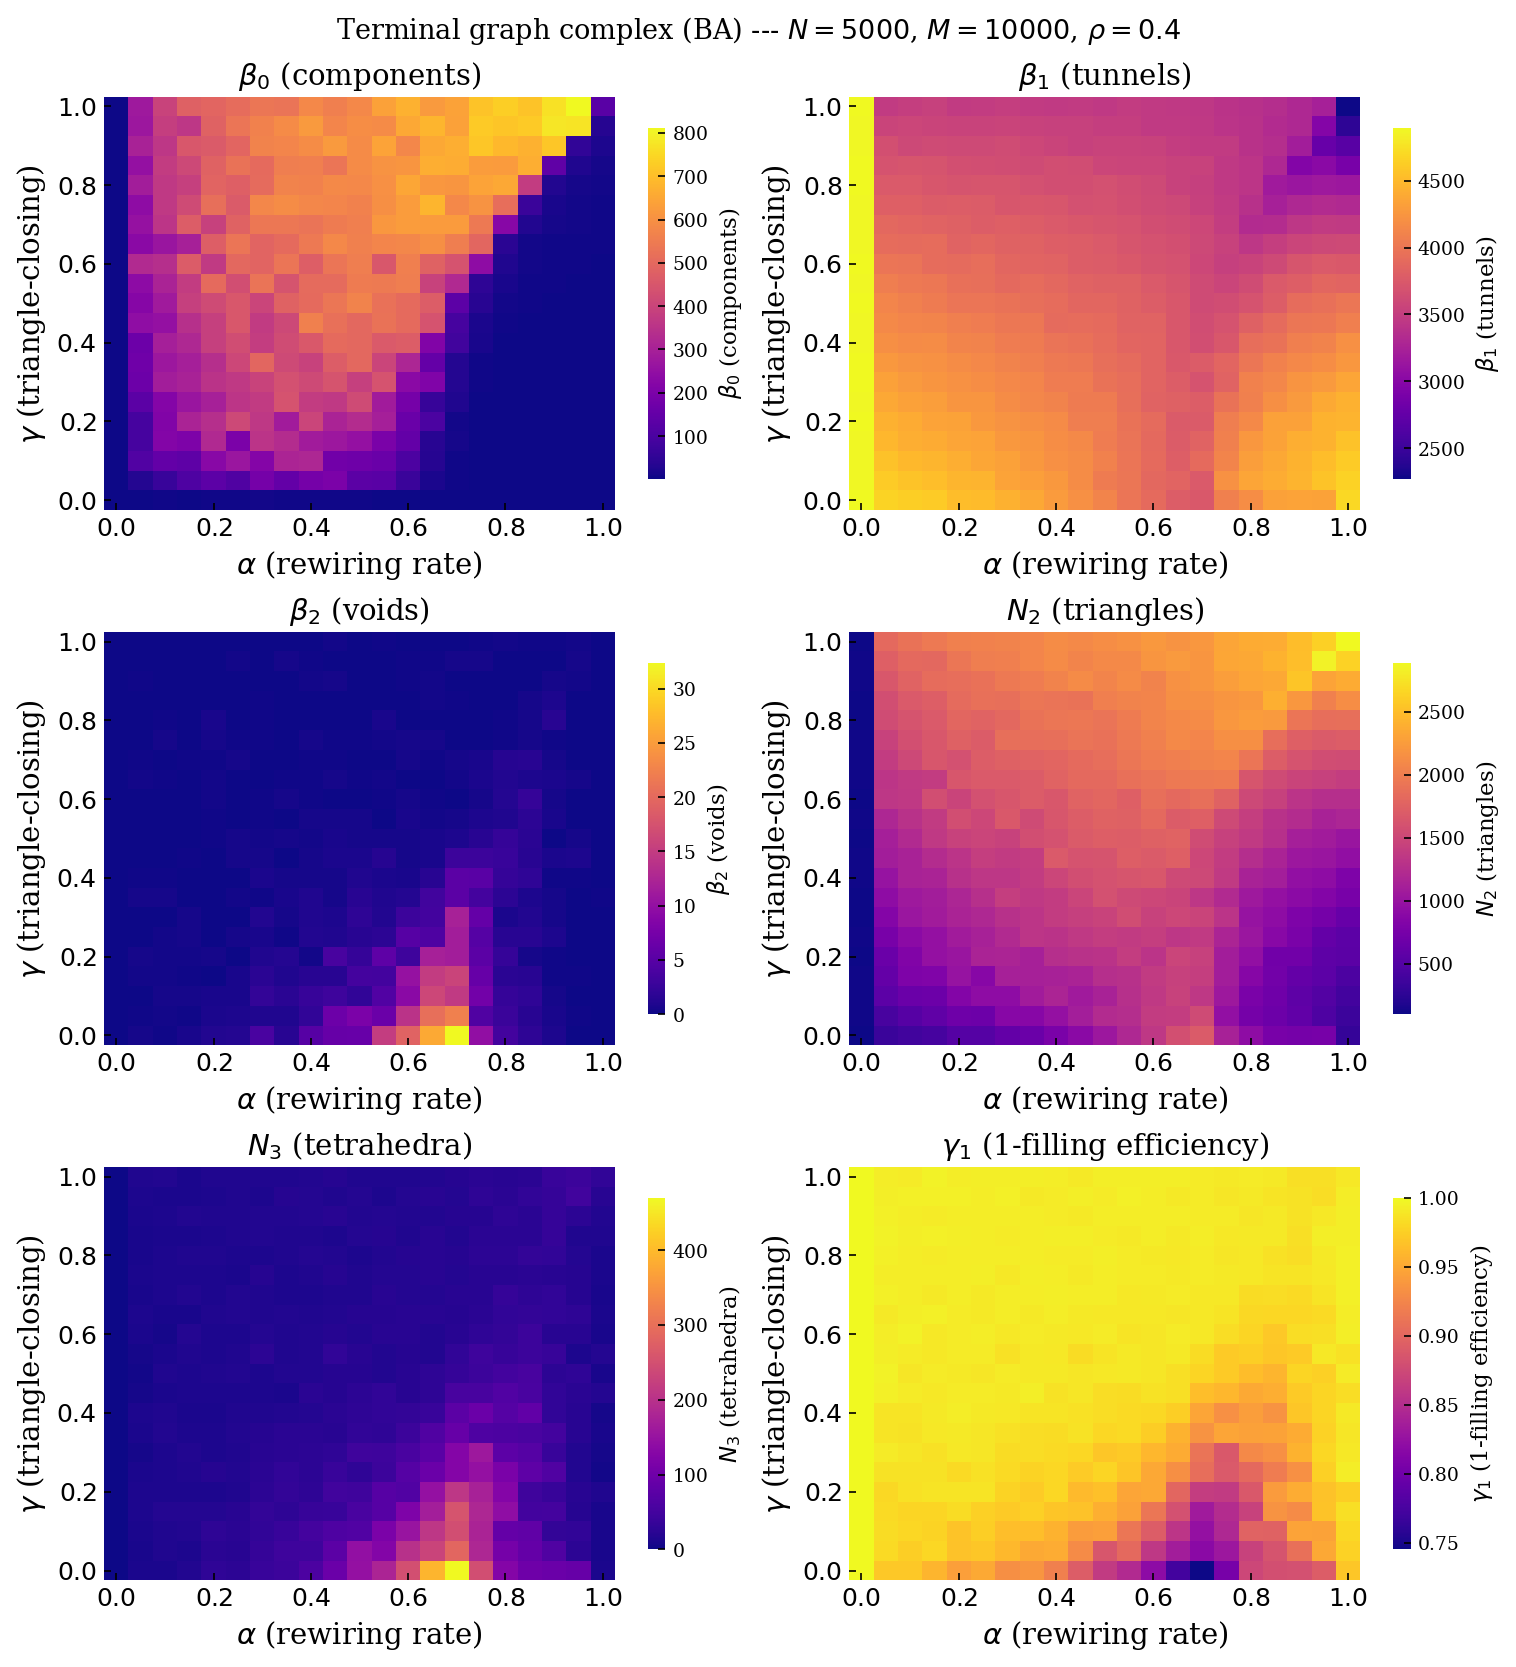

Saved: /content/drive/Othercomputers/My Computer (1)/WS/heatmap_styled_WS_n5000_m10000_rho0_4.png


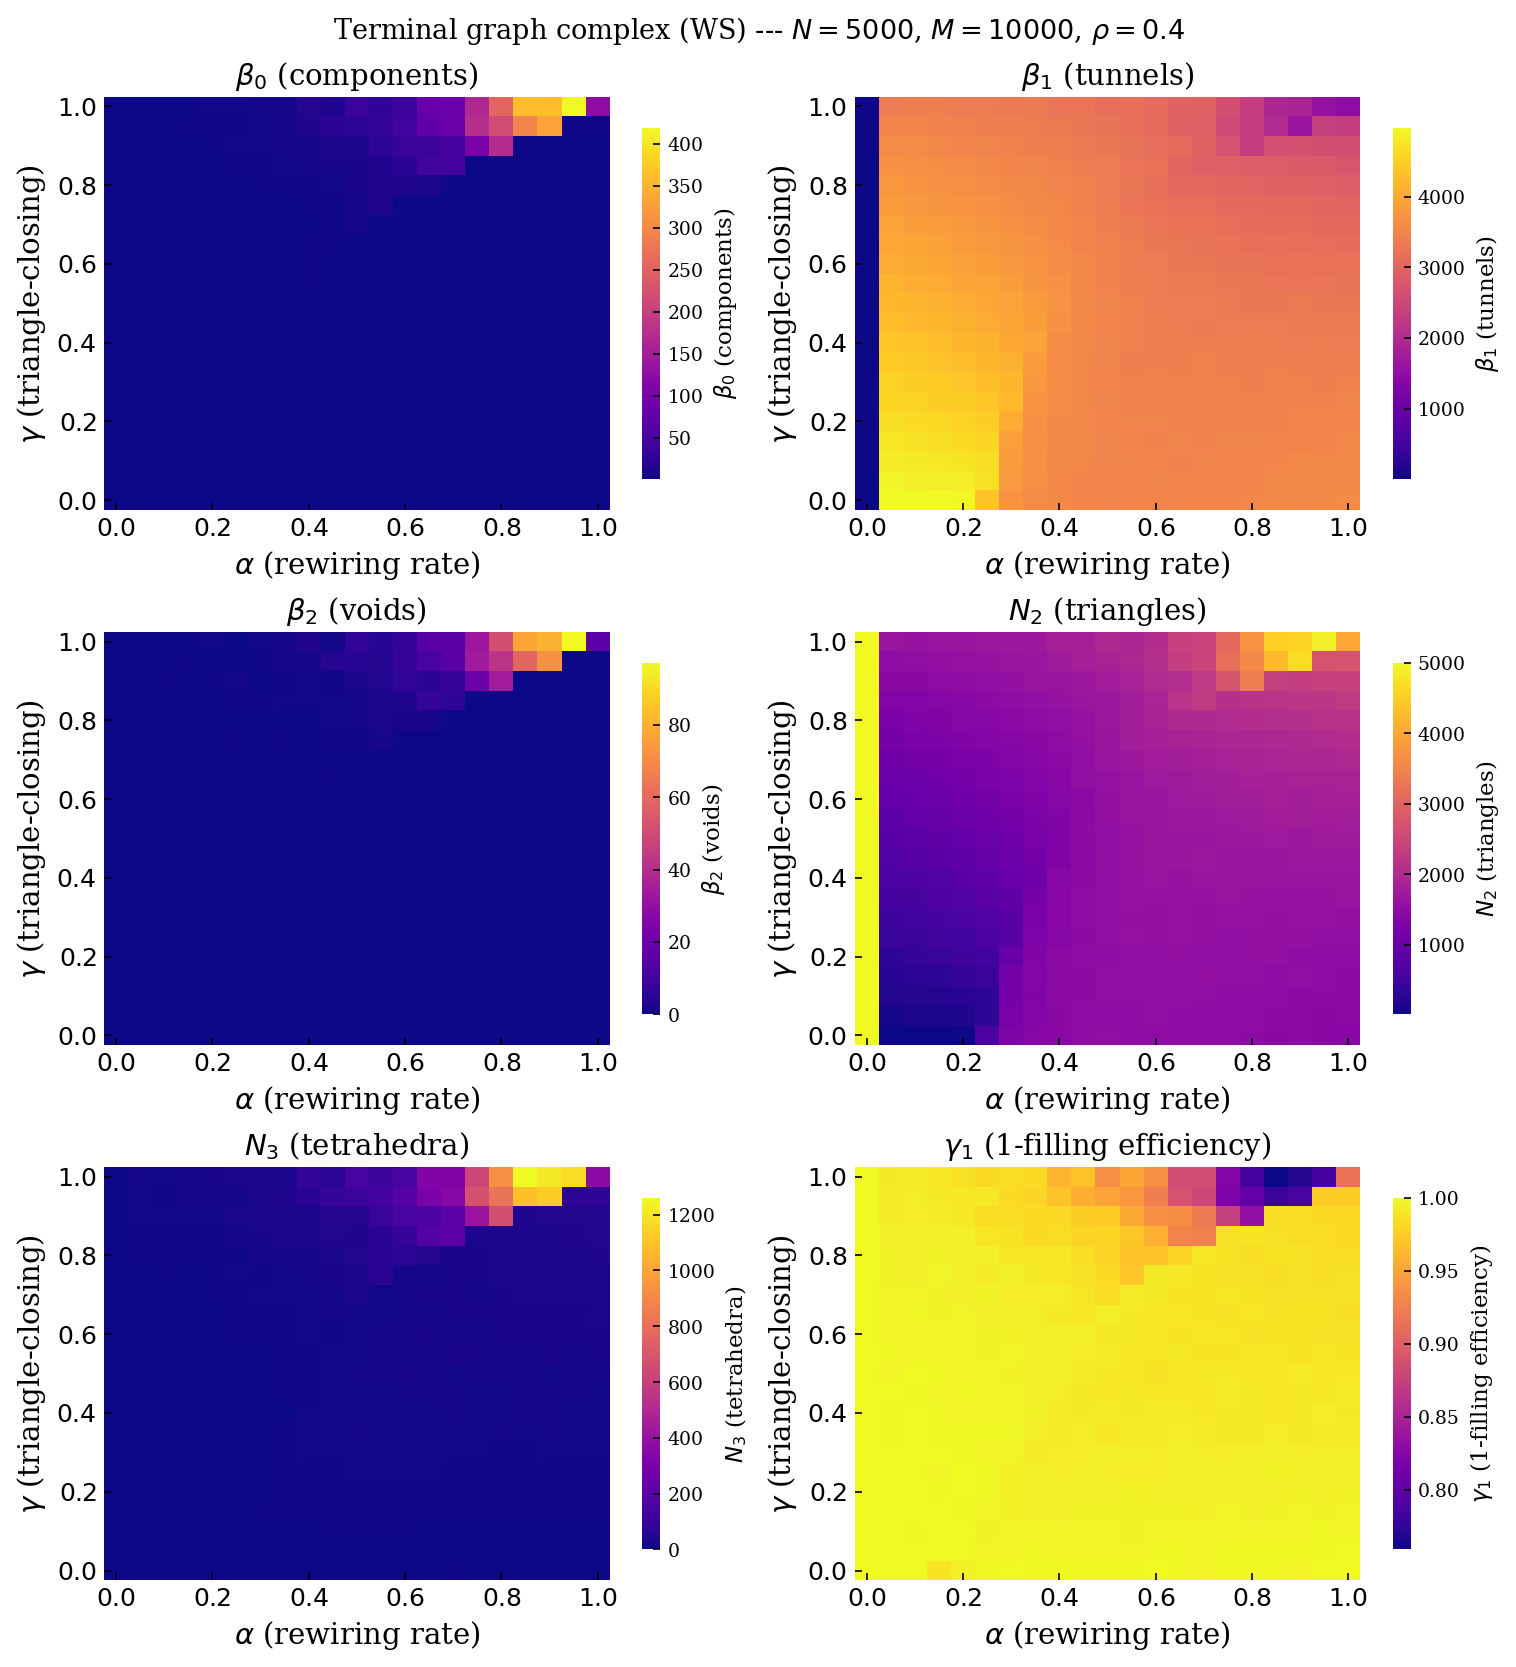

In [ ]:
MODELS     = ['BA', 'WS']
RHO        = 0.4
n, m       = 5000, 10000
alphas     = np.linspace(0, 1, 21)
gammas     = np.linspace(0, 1, 21)
iterations = range(1, 11)
na, ng     = len(alphas), len(gammas)
fields_g   = ['b0', 'b1', 'b2', 'euler', 'N0', 'N1', 'N2', 'N3']

BASE_GRAPH = ('/content/drive/Othercomputers/My Computer (1)/')

# =============================================================================
# PART I: PARALLEL COMPUTE AND SAVE
# =============================================================================

all_jobs_baws = [ (model, RHO, alpha, gamma, it)
    for model in MODELS for alpha in alphas for gamma in gammas for it in iterations]

print('Computing TDA for BA and WS graphs...')
Parallel(n_jobs=-1, backend='loky')(
    delayed(compute_and_save_baws)(BASE_GRAPH, n, m, model, rho, alpha, gamma, it)
    for model, rho, alpha, gamma, it
    in tqdm(all_jobs_baws, desc='Computing')
)

# =============================================================================
# PART II: PARALLEL LOAD AND ACCUMULATE
# =============================================================================

sums_baws   = {model: {fld: np.zeros((ng, na)) for fld in fields_g}
               for model in MODELS}
counts_baws = {model: np.zeros((ng, na)) for model in MODELS}

load_jobs = [(model, ai, gi, it)
    for model in MODELS for ai in range(na) for gi in range(ng) for it in iterations]

print('Loading BA/WS TDA results...')
results_baws = Parallel(n_jobs=-1, backend='loky')(
    delayed(load_one_baws)(BASE_GRAPH, alphas, gammas, model, ai, gi, it)
    for model, ai, gi, it in tqdm(load_jobs, desc='Submitting')
)

for out in tqdm(results_baws, desc='Accumulating'):
    if out is None:
        continue
    model, ai, gi, res = out
    for fld in fields_g:
        sums_baws[model][fld][gi, ai] += res[fld]
    counts_baws[model][gi, ai] += 1


# ── means and derived quantities ──────────────────────────────────────────────

means_baws = {model: {fld: gmean_baws(counts_baws, sums_baws, model, fld) for fld in fields_g}
              for model in MODELS}

derived_baws = {}
for model in MODELS:
    m_ = means_baws[model]
    b0, b1, b2     = m_['b0'], m_['b1'], m_['b2']
    N0, N1, N2, N3 = m_['N0'], m_['N1'], m_['N2'], m_['N3']
    euler          = m_['euler']

    with np.errstate(invalid='ignore', divide='ignore'):
        tb0   = np.where(N0 > 0, b0 / N0, np.nan)
        tb1   = np.where(N1 > 0, b1 / N1, np.nan)
        tb2   = np.where(N2 > 0, b2 / N2, np.nan)
        CR1   = N1 - N0 + b0
        CR1b1 = CR1 - b1
        g1    = np.where(N2 > 0, CR1b1 / N2, np.nan)
        CR2   = N2 - CR1 + b1
        CR2b2 = CR2 - b2
        g2    = np.where(N3 > 0, CR2b2 / N3, np.nan)

    derived_baws[model] = {
        r'$\beta_0$ (components)':                      b0,
        r'$\beta_1$ (tunnels)':                      b1,
        r'$\beta_2$ (voids)':                      b2,
        r'$N_2$ (triangles)':                          N2,
        r'$N_3$ (tetrahedra)':                          N3,
        r'$\gamma_1$ (1-filling efficiency)':                     g1,
    }

# =============================================================================
# PART III: PLOTTING
# =============================================================================

TICK_IDX = np.arange(0, na, 4)
XLABELS  = [f'${alphas[i]:.1f}$' for i in TICK_IDX]
YLABELS  = [f'${gammas[i]:.1f}$' for i in TICK_IDX]

for model in MODELS:
    plot_baws_heatmaps(n, m, RHO, derived_baws, CMAP, TICK_IDX, XLABELS, YLABELS,
        model     = model,
        save_path = os.path.join(
            BASE_GRAPH, model,
            f'heatmap_styled_{model}_n{n}_m{m}_rho{str(RHO).replace(".", "_")}.png'))

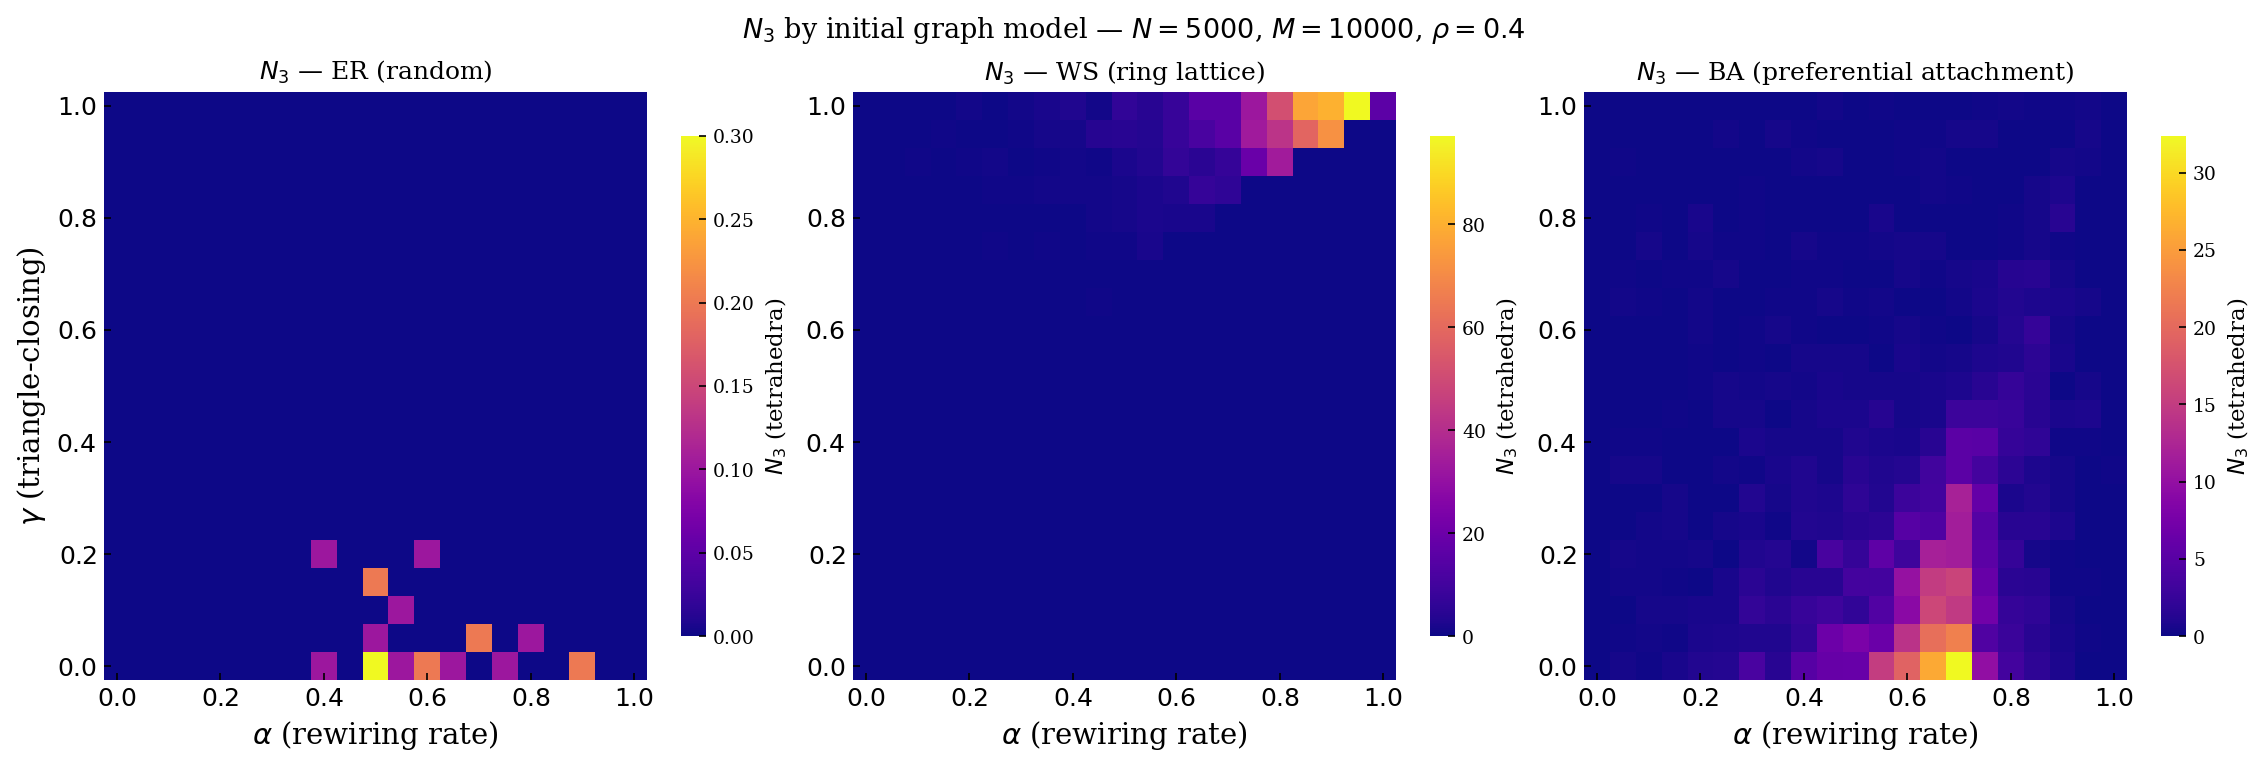

In [ ]:
plot_beta2_comparison(n, m, derived_g, derived_baws, CMAP, TICK_IDX, XLABELS, YLABELS,
    rho       = RHO,
    save_path = os.path.join(
        BASE_GRAPH,
        f'beta2_comparison_n{n}_m{m}_rho{str(RHO).replace(".", "_")}.png'))

In [ ]:
# =============================================================================
# LOAD TERMINAL PROPORTIONS DIRECTLY FROM RAW FILES
# =============================================================================

term_sums = {
    model: {'minority': np.zeros((ng, na)),
            'discord':  np.zeros((ng, na)),
            'length':   np.zeros((ng, na))}
    for model in MODELS
}
term_counts = {model: np.zeros((ng, na)) for model in MODELS}

term_jobs = [
    (model, ai, gi, it)
    for model  in MODELS
    for ai     in range(na)
    for gi     in range(ng)
    for it     in iterations
]

print('Loading terminal proportions...')
term_results = Parallel(n_jobs=-1, backend='loky')(
    delayed(load_terminal_one)(BASE_GRAPH, n, m, model, rho, alphas, gammas, ai, gi, it)
    for model, ai, gi, it in tqdm(term_jobs, desc='Submitting')
)

for out in tqdm(term_results, desc='Accumulating'):
    if out is None:
        continue
    model, ai, gi, minority, discord, length = out
    term_sums[model]['minority'][gi, ai] += minority
    term_sums[model]['discord'][gi, ai]  += discord
    term_sums[model]['length'][gi, ai]   += length
    term_counts[model][gi, ai]           += 1


# ── means ─────────────────────────────────────────────────────────────────────

term_means = {}
for model in MODELS:
    c = term_counts[model]
    with np.errstate(invalid='ignore', divide='ignore'):
        term_means[model] = {
            r'$\langle \rho_{\min} \rangle$':
                np.where(c > 0, term_sums[model]['minority'] / c, np.nan),
            r'$\langle \rho_{\mathrm{discord}} \rangle$':
                np.where(c > 0, term_sums[model]['discord']  / c, np.nan),
            r'$\langle T \rangle$':
                np.where(c > 0, term_sums[model]['length']   / c, np.nan),
        }

Loading terminal proportions...


Submitting:   0%|          | 0/8820 [00:00<?, ?it/s]

Accumulating:   0%|          | 0/8820 [00:00<?, ?it/s]

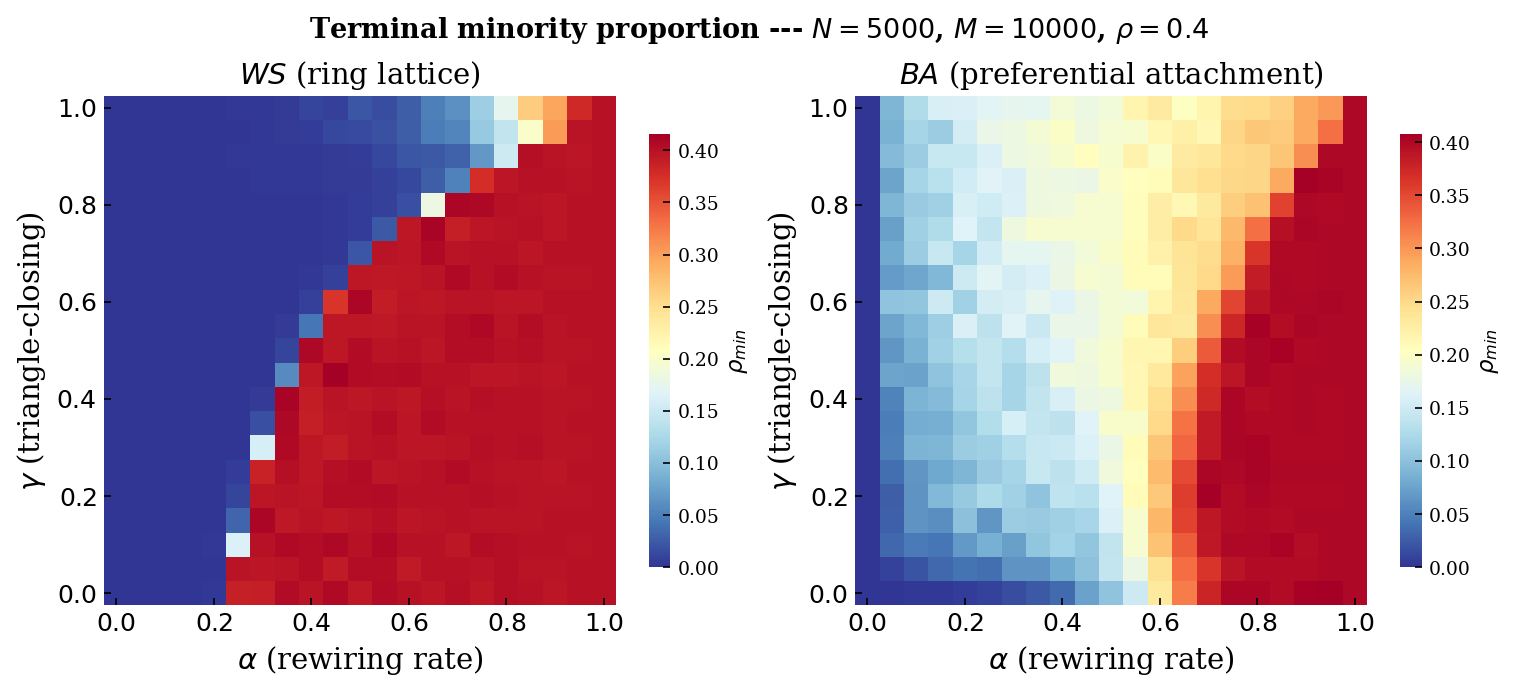

In [ ]:
plot_terminal_comparison(n, m, RHO, term_means, TICK_IDX, XLABELS, YLABELS,
    save_path=os.path.join(
        BASE_GRAPH,
        f'terminal_minority_WS_BA_n{n}_m{m}_rho{str(RHO).replace(".", "_")}.png'
    )
)

In [ ]:
# Parameters
n = 5000
m = 10000
k_values = [3, 4]
alpha_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
gamma_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
voting_values = ['Proportional']
rho = 0.5

# Base directory
base_dir = '/content/drive/My Drive/Colab Notebooks/Voter/Triangle/Arch'
os.makedirs(base_dir, exist_ok=True)

# Build list of all parameter combinations
param_list = []
for k, alpha, gamma, voting in product(k_values, alpha_values, gamma_values, voting_values):
    params = (k, alpha, gamma, voting, n, m, rho, base_dir)
    param_list.append(params)

total_runs = len(param_list)
print(f"Total simulations to run: {total_runs}")
print(f"Running in parallel...")

# Run simulations in parallel with progress bar
results = Parallel(n_jobs=4)(
    delayed(run_single_simulation)(params)
    for params in tqdm(param_list, desc="Simulations")
)

# Summary
successful = sum(1 for success, _, _ in results if success)
skipped = sum(1 for success, _, msg in results if success and msg == "Already exists")
failed = sum(1 for success, _, _ in results if not success)

print("\n" + "="*60)
print(f"Simulation Summary:")
print(f"  Total runs: {total_runs}")
print(f"  Successful: {successful}")
print(f"  Skipped (already exist): {skipped}")
print(f"  Failed: {failed}")
print("="*60)

# Print any errors
if failed > 0:
    print("\nErrors:")
    for success, filename, msg in results:
        if not success:
            print(f"  {filename}: {msg}")

print("\nAll simulations complete!")

Total simulations to run: 72
Running in parallel...


Simulations:   0%|          | 0/72 [00:00<?, ?it/s]


Simulation Summary:
  Total runs: 72
  Successful: 72
  Skipped (already exist): 72
  Failed: 0

All simulations complete!


In [ ]:
# Load all data
base_dir = '/content/drive/My Drive/Colab Notebooks/Voter/Triangle/Arch'
all_data = load_all_HG_arch_data_parallel(base_dir)

Loading 120 files in parallel...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   14.5s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   15.9s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   18.5s
[Parallel(n_jobs=-1)]: Done 118 out of 120 | elapsed:   45.4s remaining:    0.8s


Successfully loaded 120 datasets


[Parallel(n_jobs=-1)]: Done 120 out of 120 | elapsed:   55.4s finished


In [ ]:
mpl.rcParams['agg.path.chunksize'] = 10000
mpl.rcParams['path.simplify'] = True
mpl.rcParams['path.simplify_threshold'] = 1.0

# Generate one two-panel figure per K
for k in [4]:
    fig = create_HG_arch_figure_pair(
        all_data,
        k_value=k,
        save_path=f'/content/arch_plot_k{k}_both.png'
    )
    plt.show()

In [ ]:
# ── parameters ────────────────────────────────────────────────────────────────

N            = 5000
M            = 10000
K_vals       = [3, 4]
rho          = 0.4
alphas       = np.linspace(0, 1, 21)
gammas       = np.linspace(0, 1, 21)
voting_rules = ['Majority', 'Proportional']
iterations   = [1, 2, 3, 4, 5]
EXIT         = 100_000_000

data_base = '/content/drive/Othercomputers/My Computer (1)/ER/'
save_base = '/content/drive/Othercomputers/My Computer (1)/ER/'

# ── filename helper ───────────────────────────────────────────────────────────

def make_filename(n, m, k, rho, alpha, gamma, voting, iteration):
    return (
        data_base +
        f'H_rewire_triangle_same_ER_{n}_{m}_{k}_'
        f'{str(rho).replace(".","_")}_'
        f'{str(alpha).replace(".","_")}_'
        f'{str(gamma).replace(".","_")}_'
        f'{voting}_{iteration}.pkl'
    )

# ── load one file ─────────────────────────────────────────────────────────────

def load_one(n, m, k, rho, alpha, gamma, voting, iteration):
    fname = make_filename(n, m, k, rho, alpha, gamma, voting, iteration)
    if not os.path.isfile(fname):
        return (k, voting, alpha, gamma, iteration), None, None
    try:
        with gzip.open(fname, 'rb') as f:
            proportion, _, timer, _ = pickle.load(f)
        term_prop  = float(proportion)
        term_timer = int(timer)
        return (k, voting, alpha, gamma, iteration), min(1-term_prop,term_prop), term_timer
    except Exception as e:
        print(f'  Error {fname}: {e}')
        return (k, voting, alpha, gamma, iteration), None, None

# ── parallel load ─────────────────────────────────────────────────────────────

all_params = list(product(K_vals, voting_rules,
                          range(len(alphas)), range(len(gammas)), iterations))

def _load_wrapper(args):
    k, v, ai, gi, it = args
    _, prop, timer = load_one(N, M, k, rho, alphas[ai], gammas[gi], v, it)
    return (k, v, ai, gi, it), prop, timer

print('Loading data...')
raw_results = Parallel(n_jobs=-1, backend='loky')(
    delayed(_load_wrapper)(p)
    for p in tqdm(all_params, desc='Loading')
)

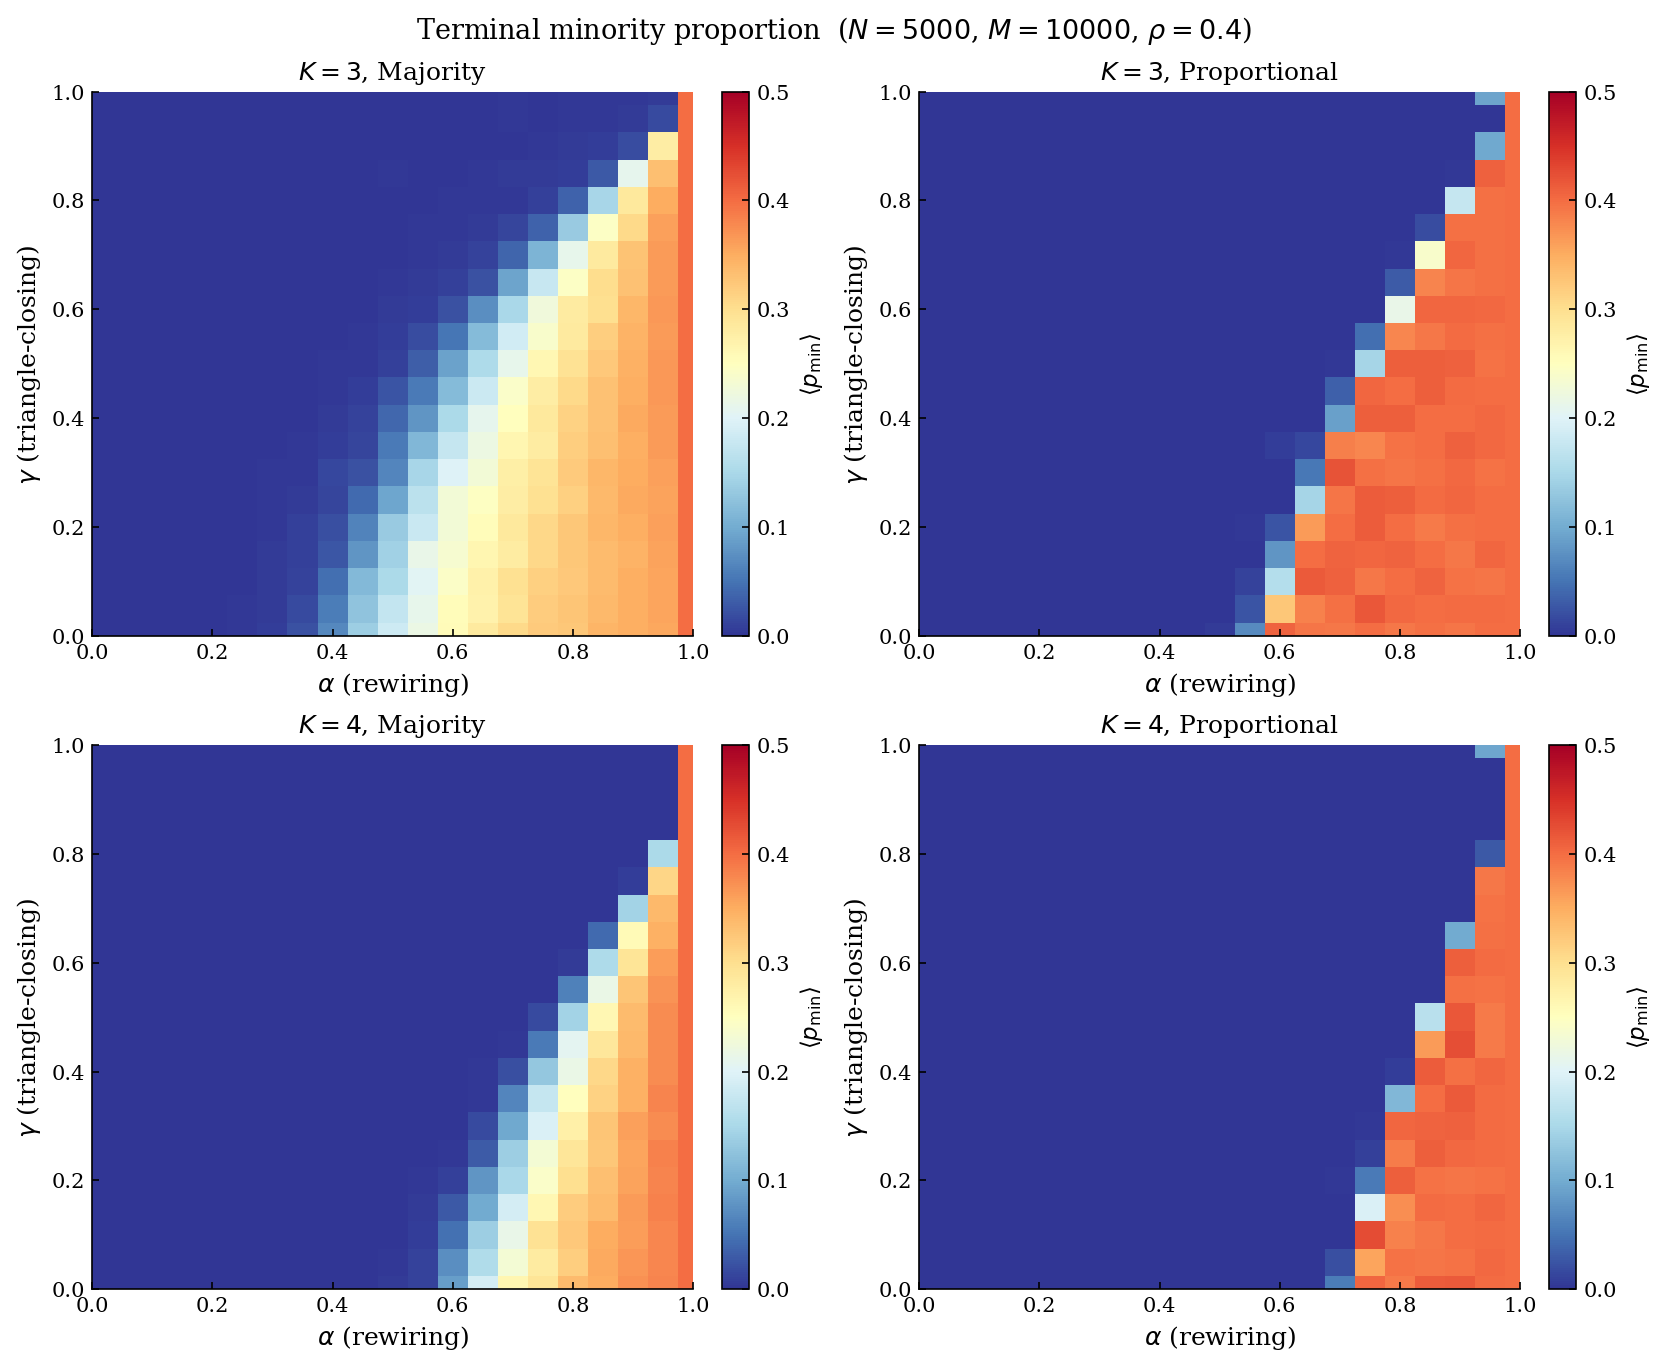

Saved: fig_HG_RTSame_proportion


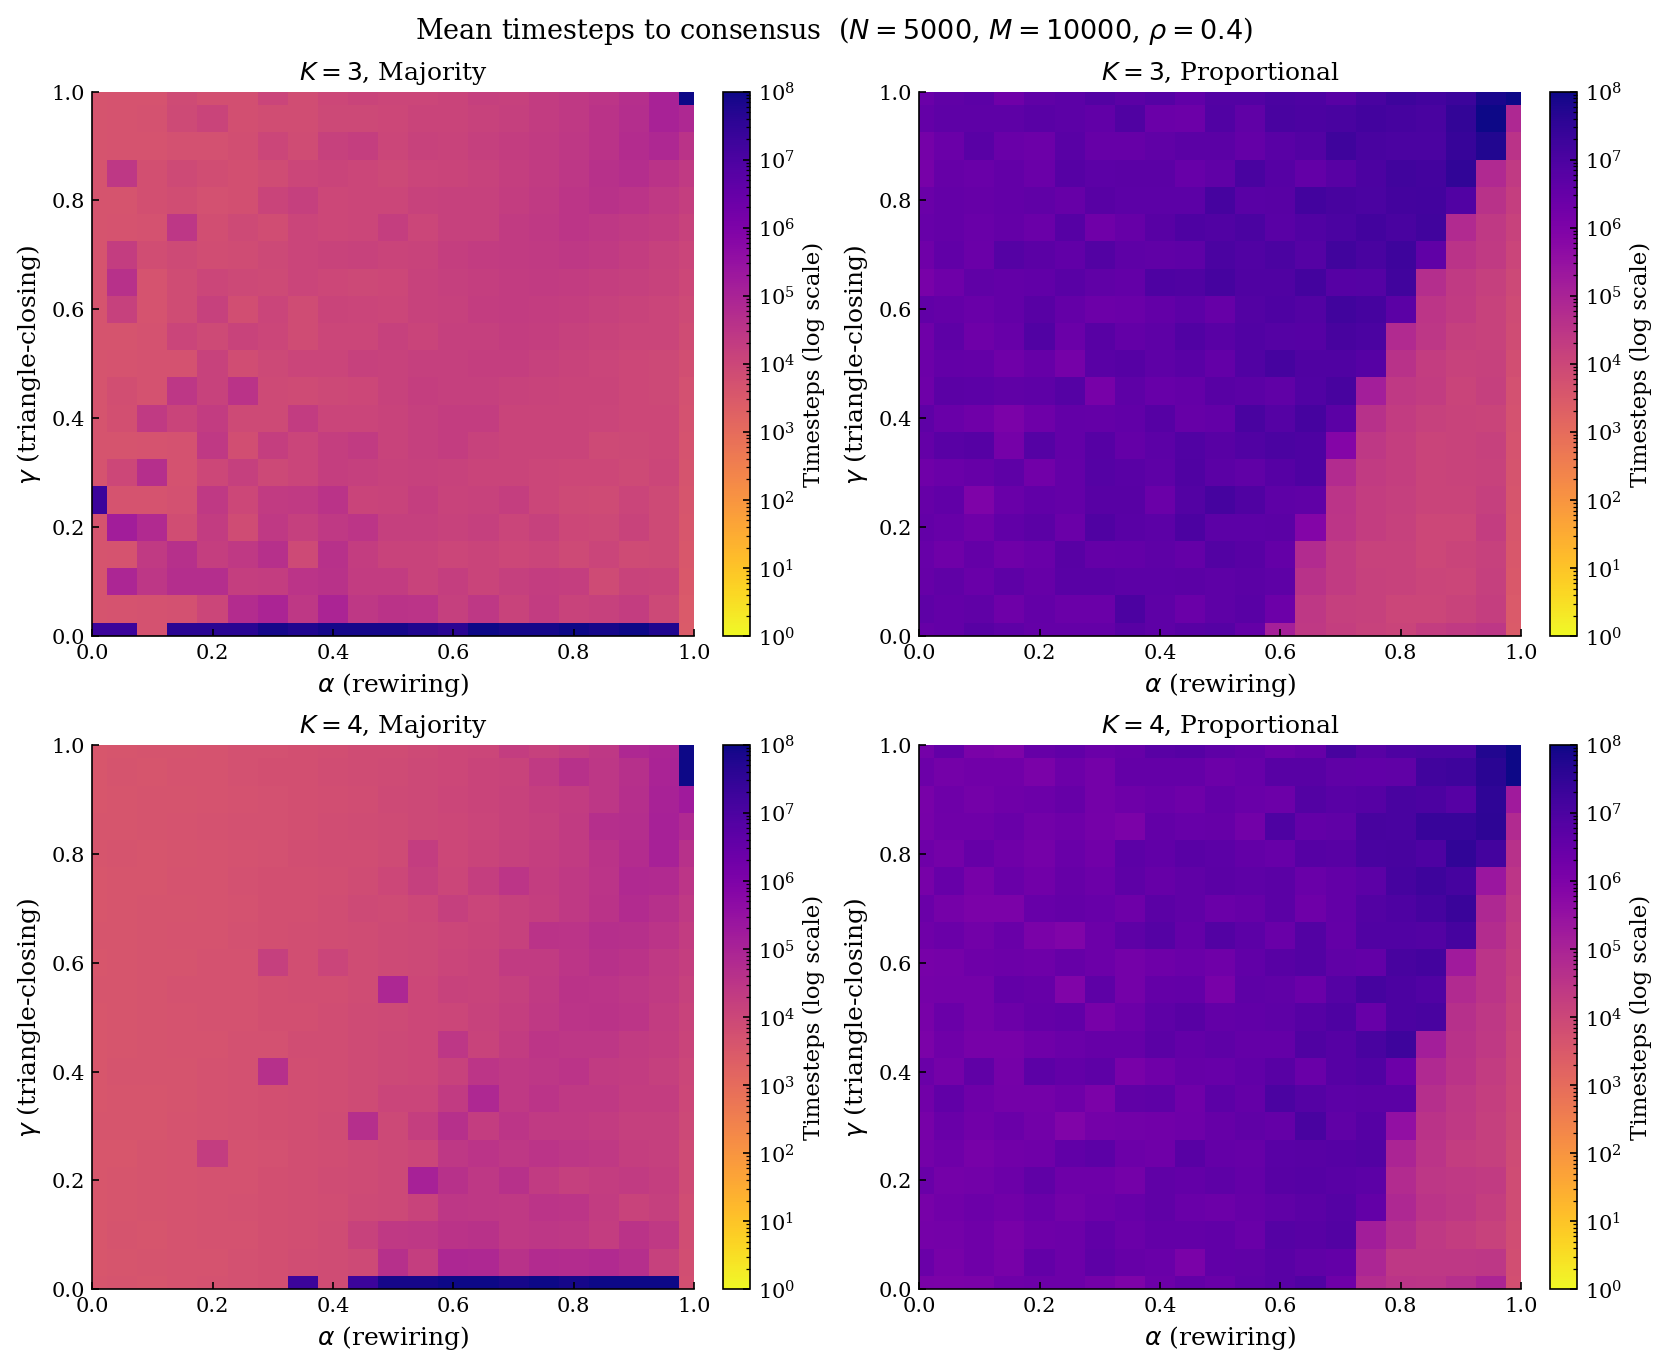

Saved: fig_HG_RTSame_timer


In [ ]:
# ── assemble into mean arrays: prop_data[k][voting] → (n_gamma, n_alpha) ─────

na, ng = len(alphas), len(gammas)

prop_sum   = {k: {v: np.zeros((ng, na)) for v in voting_rules} for k in K_vals}
timer_sum  = {k: {v: np.zeros((ng, na)) for v in voting_rules} for k in K_vals}
count      = {k: {v: np.zeros((ng, na)) for v in voting_rules} for k in K_vals}
no_consens = {k: {v: np.zeros((ng, na)) for v in voting_rules} for k in K_vals}

for (k, v, ai, gi, it), prop, timer in raw_results:
    if prop is None:
        continue
    prop_sum[k][v][gi, ai]  += prop
    timer_sum[k][v][gi, ai] += timer
    count[k][v][gi, ai]     += 1
    if timer >= EXIT:
        no_consens[k][v][gi, ai] += 1

def safe_mean(s, c):
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(c > 0, s / c, np.nan)

prop_mean  = {k: {v: safe_mean(prop_sum[k][v],  count[k][v]) for v in voting_rules}
              for k in K_vals}
timer_mean = {k: {v: safe_mean(timer_sum[k][v], count[k][v]) for v in voting_rules}
              for k in K_vals}
frac_nc    = {k: {v: safe_mean(no_consens[k][v], count[k][v]) for v in voting_rules}
              for k in K_vals}

# ── heatmap helper ────────────────────────────────────────────────────────────

def heatmap(ax, mat, alphas, gammas, cmap, vmin, vmax, title, cbar_label,
            norm=None):
    im = ax.pcolormesh(
        alphas, gammas, mat,
        cmap=cmap, shading='auto',
        norm=norm if norm is not None else mcolors.Normalize(vmin=vmin, vmax=vmax),
    )
    ax.set_xlabel(r'$\alpha$ (rewiring)')
    ax.set_ylabel(r'$\gamma$ (triangle-closing)')
    ax.set_title(title, pad=6)
    ax.set_xlim(alphas[0], alphas[-1])
    ax.set_ylim(gammas[0], gammas[-1])
    return im

# ── Figure 1: terminal minority proportion ────────────────────────────────────
# Rows: K=3 (top), K=4 (bottom)
# Cols: Majority (left), Proportional (right)

fig1, axes1 = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
fig1.suptitle(
    rf'Terminal minority proportion  ($N={N}$, $M={M}$, $\rho={rho}$)',
    fontsize=13
)

prop_vmin = 0.0
prop_vmax = 0.5

for row, k in enumerate(K_vals):
    for col, v in enumerate(voting_rules):
        ax  = axes1[row, col]
        mat = prop_mean[k][v]
        im  = heatmap(ax, mat, alphas, gammas,
                      cmap='RdYlBu_r',
                      vmin=prop_vmin, vmax=prop_vmax,
                      title=rf'$K={k}$, {v}',
                      cbar_label=r'$\langle p_{\min} \rangle$')
        cbar = fig1.colorbar(im, ax=ax, pad=0.02)
        cbar.set_label(r'$\langle p_{\min} \rangle$', fontsize=11)

fig1.savefig(save_base + 'fig_HG_RTSame_proportion.pdf',
             dpi=300, bbox_inches='tight')
fig1.savefig(save_base + 'fig_HG_RTSame_proportion.png',
             dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_HG_RTSame_proportion')

# ── Figure 2: timer (timesteps to consensus) ──────────────────────────────────
# Use log scale; cells where all runs hit EXIT are hatched

fig2, axes2 = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
fig2.suptitle(
    rf'Mean timesteps to consensus  ($N={N}$, $M={M}$, $\rho={rho}$)',
    fontsize=13
)

log_norm = mcolors.LogNorm(vmin=1, vmax=EXIT)

for row, k in enumerate(K_vals):
    for col, v in enumerate(voting_rules):
        ax   = axes2[row, col]
        mat  = timer_mean[k][v].copy()
        fnc  = frac_nc[k][v]

        im = heatmap(ax, mat, alphas, gammas,
                     cmap='plasma_r',
                     vmin=None, vmax=None,
                     norm=log_norm,
                     title=rf'$K={k}$, {v}',
                     cbar_label='Timesteps')

        # hatch cells where ≥ 50 % of runs did not reach consensus
        nc_mask = np.ma.masked_where(fnc < 0.5, np.ones_like(fnc))
        ax.pcolor(alphas, gammas, nc_mask,
                  hatch='////', alpha=0.0, edgecolor='white', linewidth=0.3)

        cbar = fig2.colorbar(im, ax=ax, pad=0.02)
        cbar.set_label('Timesteps (log scale)', fontsize=11)

fig2.savefig(save_base + 'fig_HG_RTSame_timer.pdf',
             dpi=300, bbox_inches='tight')
fig2.savefig(save_base + 'fig_HG_RTSame_timer.png',
             dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_HG_RTSame_timer')

In [ ]:
# ── parameters ────────────────────────────────────────────────────────────────

N_nodes      = 5000
M            = 10000
K_vals       = [3, 4]
rho          = 0.4
alphas       = np.linspace(0, 1, 21)
gammas       = np.linspace(0, 1, 21)
voting_rules = ['Majority', 'Proportional']
iterations   = [1, 2, 3, 4, 5]
MAX_DIM      = 3    # max simplex dimension → max simplex size = 4

data_base = '/content/drive/Othercomputers/My Computer (1)/ER/'
proc_base = '/content/drive/Othercomputers/My Computer (1)/ER/Processed/'
save_base = '/content/drive/Othercomputers/My Computer (1)/ER/'
os.makedirs(proc_base, exist_ok=True)
os.makedirs(save_base,  exist_ok=True)

# ── filename helpers ──────────────────────────────────────────────────────────

def raw_filename(k, alpha, gamma, voting, iteration):
    return (
        data_base +
        f'H_rewire_triangle_same_ER_{N_nodes}_{M}_{k}_'
        f'{str(rho).replace(".","_")}_'
        f'{str(alpha).replace(".","_")}_'
        f'{str(gamma).replace(".","_")}_'
        f'{voting}_{iteration}.pkl'
    )

def proc_filename(k, alpha, gamma, voting, iteration):
    return (
        proc_base +
        f'TDA_ER_{N_nodes}_{M}_{k}_'
        f'{str(rho).replace(".","_")}_'
        f'{str(alpha).replace(".","_")}_'
        f'{str(gamma).replace(".","_")}_'
        f'{voting}_{iteration}.pkl'
    )

# ── TDA computation ───────────────────────────────────────────────────────────

def downward_closure(H, max_dim):
    """
    Build all simplices in the downward closure of H up to dimension max_dim.
    Returns list of sets, one per dimension 0..max_dim.
    Each element is a set of tuples (sorted vertex lists).
    """
    simplices = [set() for _ in range(max_dim + 1)]
    for nodes in H.values():
        nodes = sorted(nodes)
        # include subsets of size 1..(max_dim+1)
        for size in range(1, min(len(nodes) + 1, max_dim + 2)):
            for subset in combinations(nodes, size):
                simplices[size - 1].add(subset)
    return simplices

def compute_tda(H, max_dim=MAX_DIM):
    """
    Build a dimension-filtered complex from H, compute PH via dionysus2.
    Filtration time = simplex dimension (0-simplices at t=0, etc.).

    Returns dict with:
        b0, b1, b2        : terminal Betti numbers
        N0, N1, N2, N3    : simplex counts per dimension
    """
    simplices = downward_closure(H, max_dim)

    # build dionysus filtration: time = dimension
    f = d.Filtration()
    for dim, sset in enumerate(simplices):
        for s in sset:
            f.append(d.Simplex(list(s), float(dim)))
    f.sort()

    # persistent homology
    m    = d.homology_persistence(f)
    dgms = d.init_diagrams(m, f)

    # terminal Betti numbers = count of infinite bars in each diagram
    inf = float('inf')
    b = [0, 0, 0]
    for dim in range(3):
        if dim < len(dgms):
            b[dim] = sum(1 for pt in dgms[dim] if pt.death == inf)

    counts = [len(s) for s in simplices]   # N0, N1, N2, N3
    while len(counts) < 4:
        counts.append(0)

    return {
        'b0': b[0], 'b1': b[1], 'b2': b[2],
        'N0': counts[0], 'N1': counts[1],
        'N2': counts[2], 'N3': counts[3],
    }

# ── process one (k, alpha, gamma, voting, iteration) ─────────────────────────

def process_one(k, ai, gi, voting, it):
    alpha = alphas[ai]; gamma = gammas[gi]
    pfname = proc_filename(k, alpha, gamma, voting, it)
    if os.path.isfile(pfname):
        return  # already processed

    rfname = raw_filename(k, alpha, gamma, voting, it)
    if not os.path.isfile(rfname):
        return

    try:
        with gzip.open(rfname, 'rb') as f:
            _, _, _, H = pickle.load(f)
        result = compute_tda(H)
        with gzip.open(pfname, 'wb') as f:
            pickle.dump(result, f)
    except Exception as e:
        print(f'  Error [{k}, a={alpha:.2f}, g={gamma:.2f}, {voting}, {it}]: {e}')

# ── parallel processing ───────────────────────────────────────────────────────

all_jobs = list(product(K_vals, range(len(alphas)), range(len(gammas)),
                        voting_rules, iterations))

from joblib import Parallel, delayed

print('Computing TDA...')
Parallel(n_jobs=-1, backend='threading')(
    delayed(process_one)(k, ai, gi, v, it)
    for k, ai, gi, v, it in tqdm(all_jobs, desc='TDA')
)
print('TDA complete.')

Computing TDA...


TDA: 100%|██████████| 8820/8820 [00:31<00:00, 278.83it/s] 

TDA complete.


In [ ]:
# =============================================================================
# LOADING AND PLOTTING
# =============================================================================

na, ng = len(alphas), len(gammas)

fields = ['b0', 'b1', 'b2', 'N0', 'N1', 'N2', 'N3']
sums   = {k: {v: {fld: np.zeros((ng, na)) for fld in fields}
              for v in voting_rules} for k in K_vals}
counts = {k: {v: np.zeros((ng, na)) for v in voting_rules} for k in K_vals}

# ── parallel load ─────────────────────────────────────────────────────────────

def load_one(k, ai, gi, v, it):
    alpha  = alphas[ai]; gamma = gammas[gi]
    pfname = proc_filename(k, alpha, gamma, v, it)
    if not os.path.isfile(pfname):
        return None
    try:
        with gzip.open(pfname, 'rb') as f:
            res = pickle.load(f)
        return (k, ai, gi, v, res)
    except Exception:
        return None

print('Loading processed TDA...')
results = Parallel(n_jobs=-1, backend='loky')(
    delayed(load_one)(k, ai, gi, v, it)
    for k, ai, gi, v, it in tqdm(all_jobs, desc='Submitting')
)

# ── serial accumulation (fast, no contention) ─────────────────────────────────
for out in tqdm(results, desc='Accumulating'):
    if out is None:
        continue
    k, ai, gi, v, res = out
    for fld in fields:
        sums[k][v][fld][gi, ai] += res[fld]
    counts[k][v][gi, ai] += 1

# ── compute means and derived quantities ──────────────────────────────────────

def smean(k, v, fld):
    c = counts[k][v]
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(c > 0, sums[k][v][fld] / c, np.nan)

means = {k: {v: {fld: smean(k, v, fld) for fld in fields}
             for v in voting_rules} for k in K_vals}

# derived quantities
derived = {}
for k in K_vals:
    derived[k] = {}
    for v in voting_rules:
        m = means[k][v]
        b0, b1, b2 = m['b0'], m['b1'], m['b2']
        N0, N1, N2, N3 = m['N0'], m['N1'], m['N2'], m['N3']

        with np.errstate(invalid='ignore', divide='ignore'):
            tb0   = np.where(N0 > 0, b0 / N0, np.nan)
            tb1   = np.where(N1 > 0, b1 / N1, np.nan)
            tb2   = np.where(N2 > 0, b2 / N2, np.nan)
            CR1   = N1 - N0 + b0
            CR1b1 = CR1 - b1
            g1    = np.where(N2 > 0, CR1b1 / N2, np.nan)
            CR2   = N2 - CR1 + b1
            CR2b2 = CR2 - b2
            g2    = np.where(N3 > 0, CR2b2 / N3, np.nan)

        derived[k][v] = {
            r'$\beta_0$ (connected components)':                             b0,
            #r'$\tilde{\beta}_0$':                     tb0,
            r'$\beta_1$ (tunnels)':                             b1,
            #r'$\tilde{\beta}_1$':                     tb1,
            r'$\beta_2$ (voids)':                             b2,
            #r'$\tilde{\beta}_2$':                     tb2,
            r'$N_1$ (inferred edges)':                                 N1,
            r'$N_2$ (triangles)':                                 N2,
            r'$N_3$ (tetrahedra)':                                 N3,
            #r'$\mathcal{CR}_1 - \beta_1$':            CR1b1,
            #r'$\gamma_1$':                            g1,
            #r'$\mathcal{CR}_2 - \beta_2$':            CR2b2,
            #r'$\gamma_2$':                            g2,
        }

Loading processed TDA...


Accumulating: 100%|██████████| 8820/8820 [00:00<00:00, 220829.27it/s]


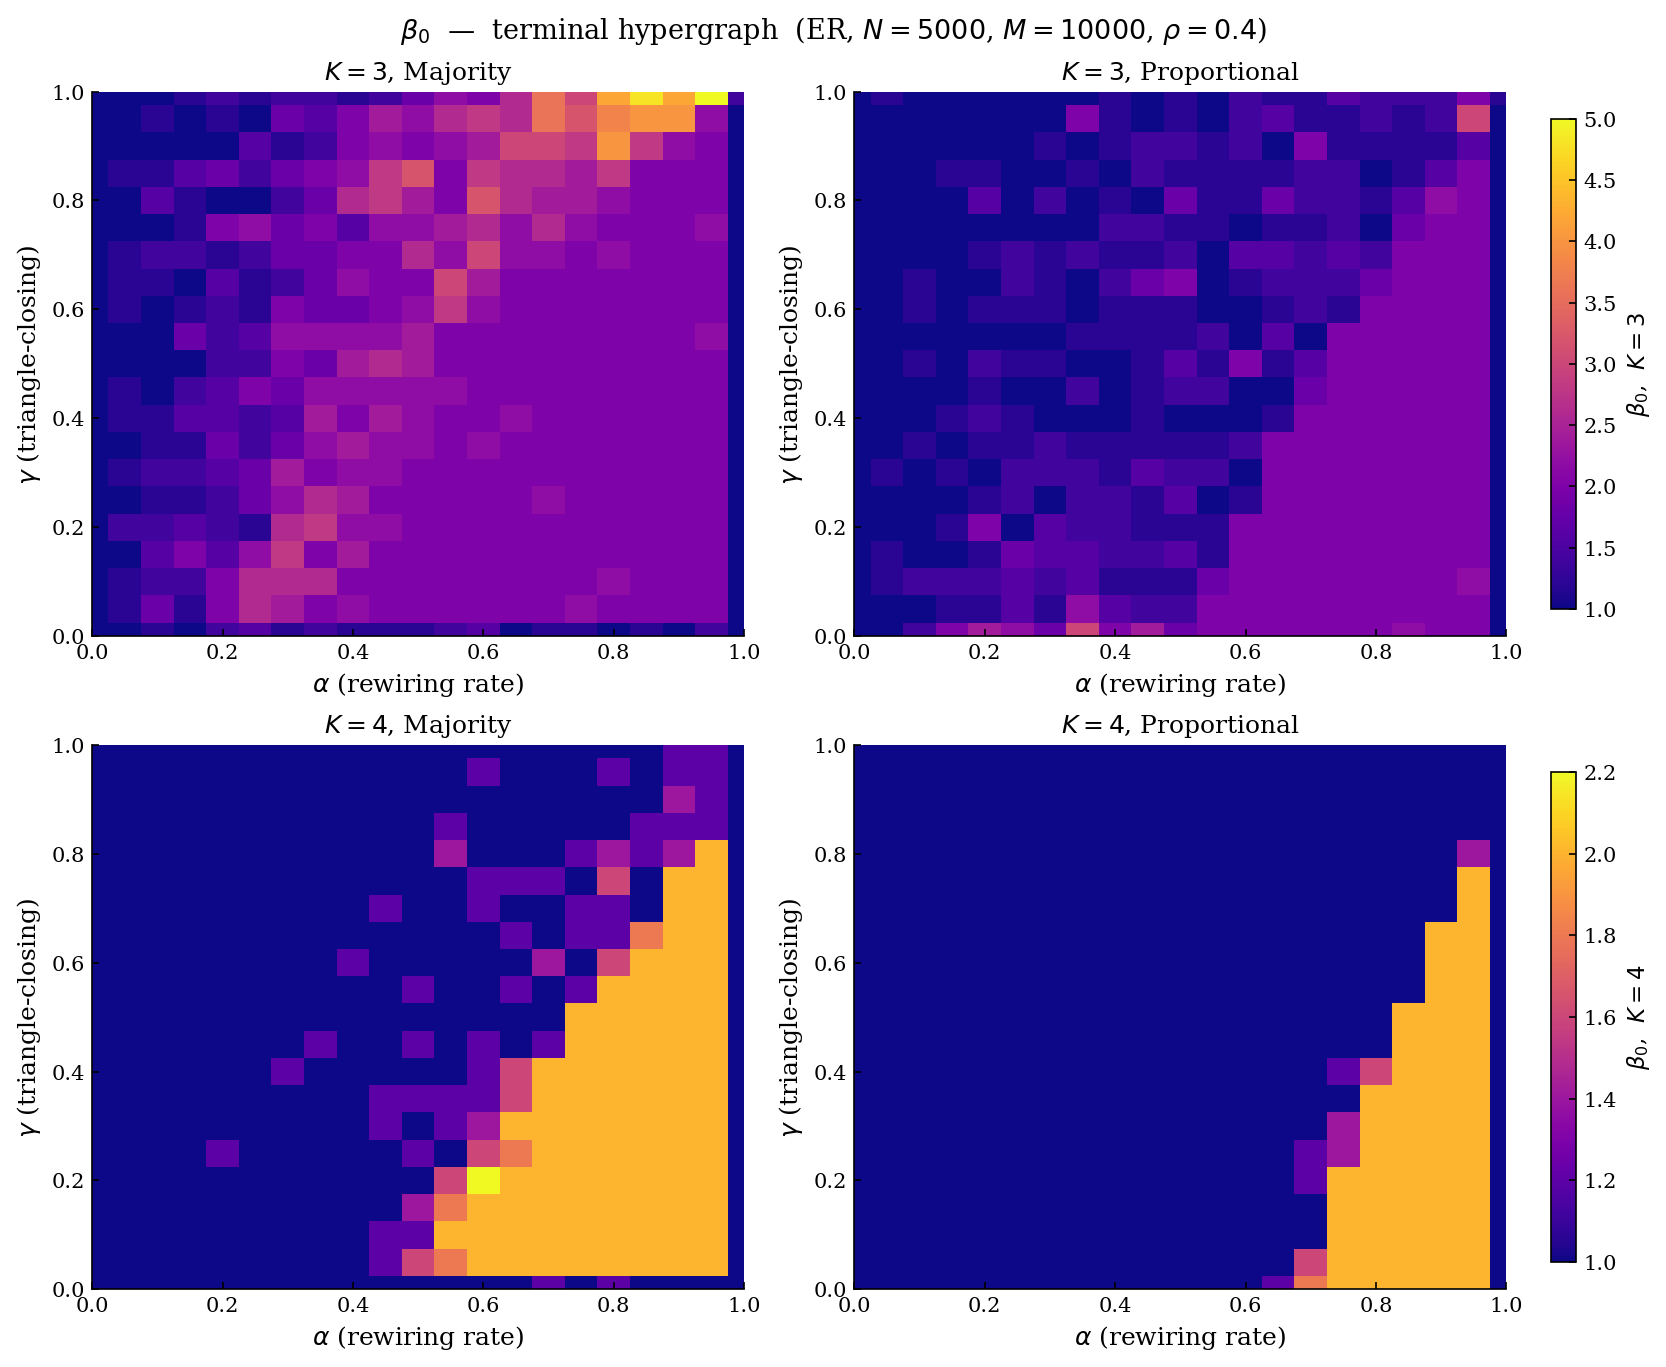

Saved: beta_0


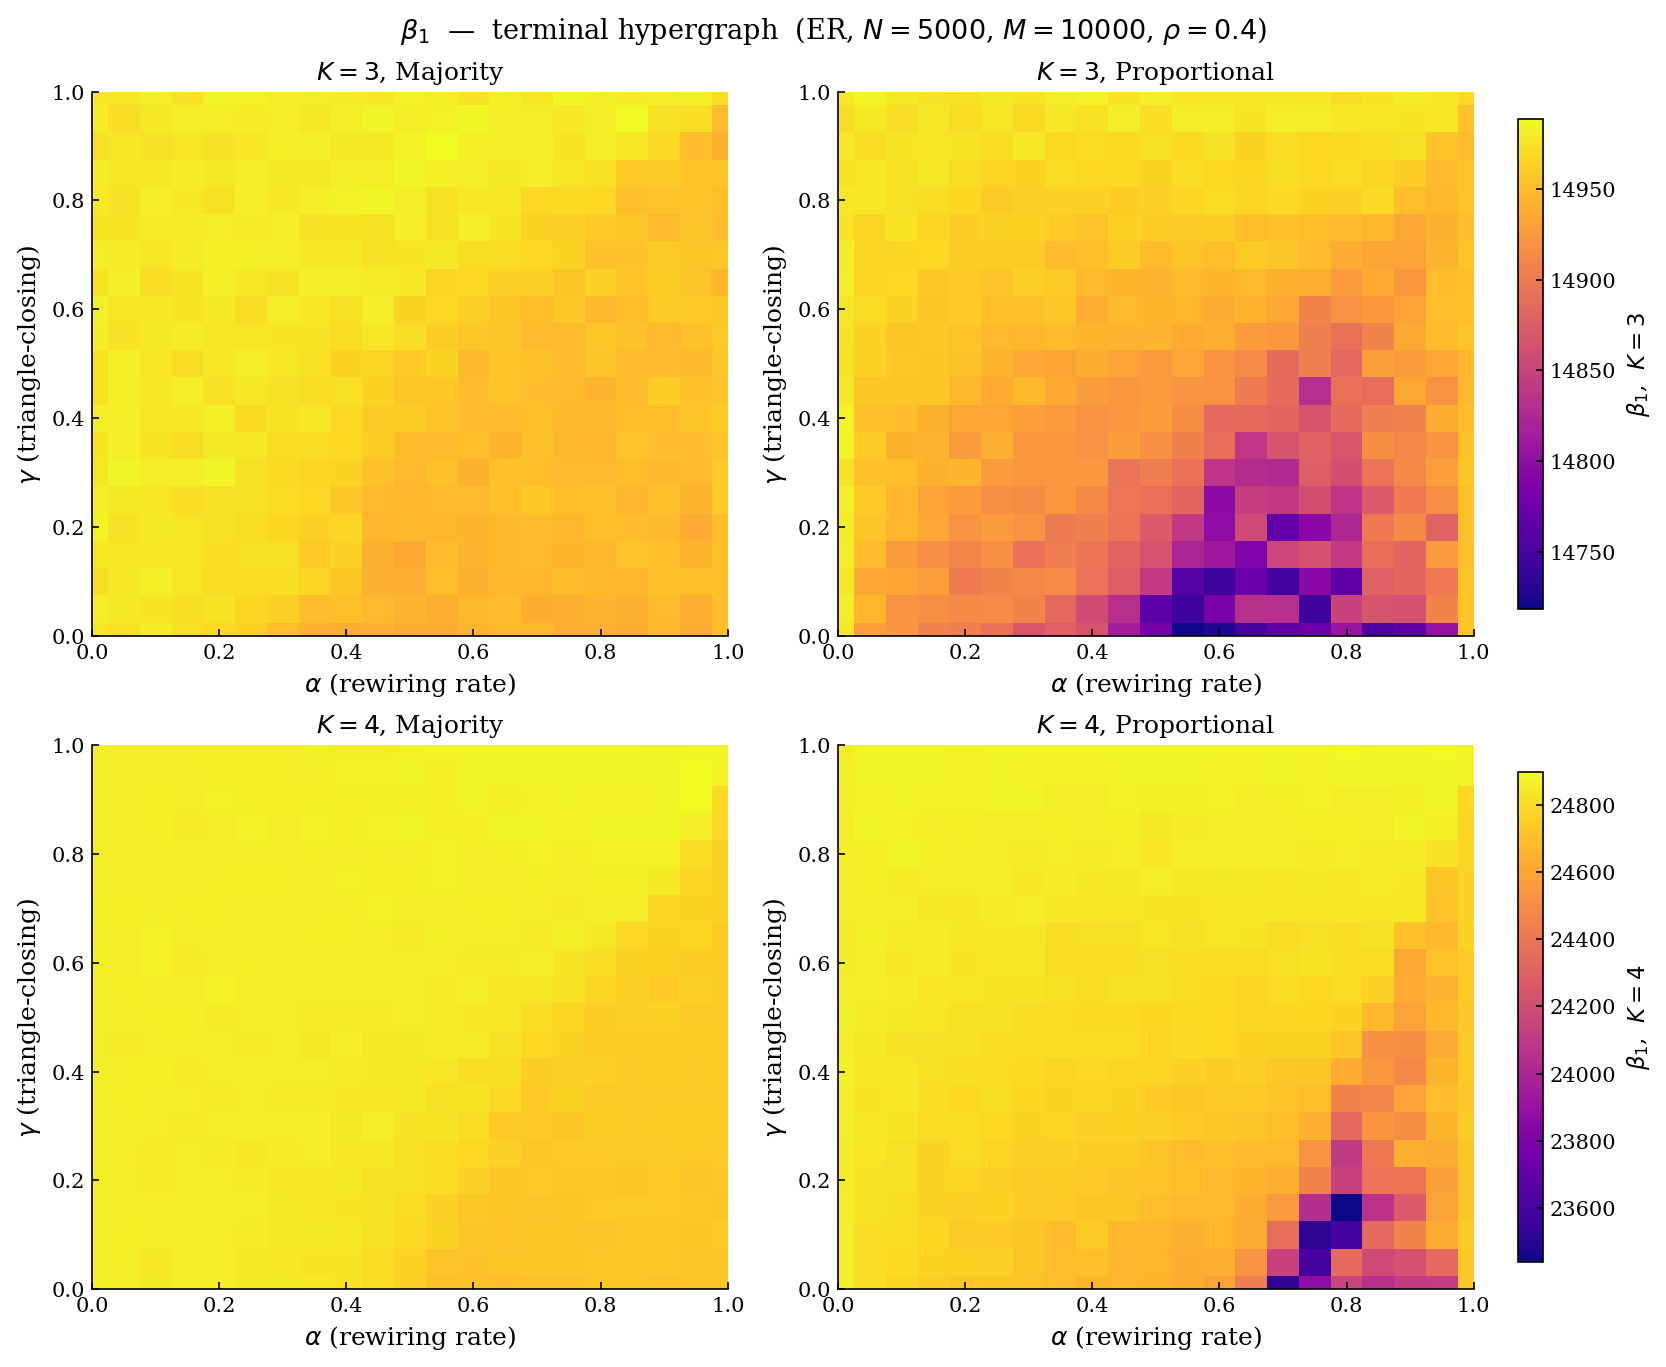

Saved: beta_1


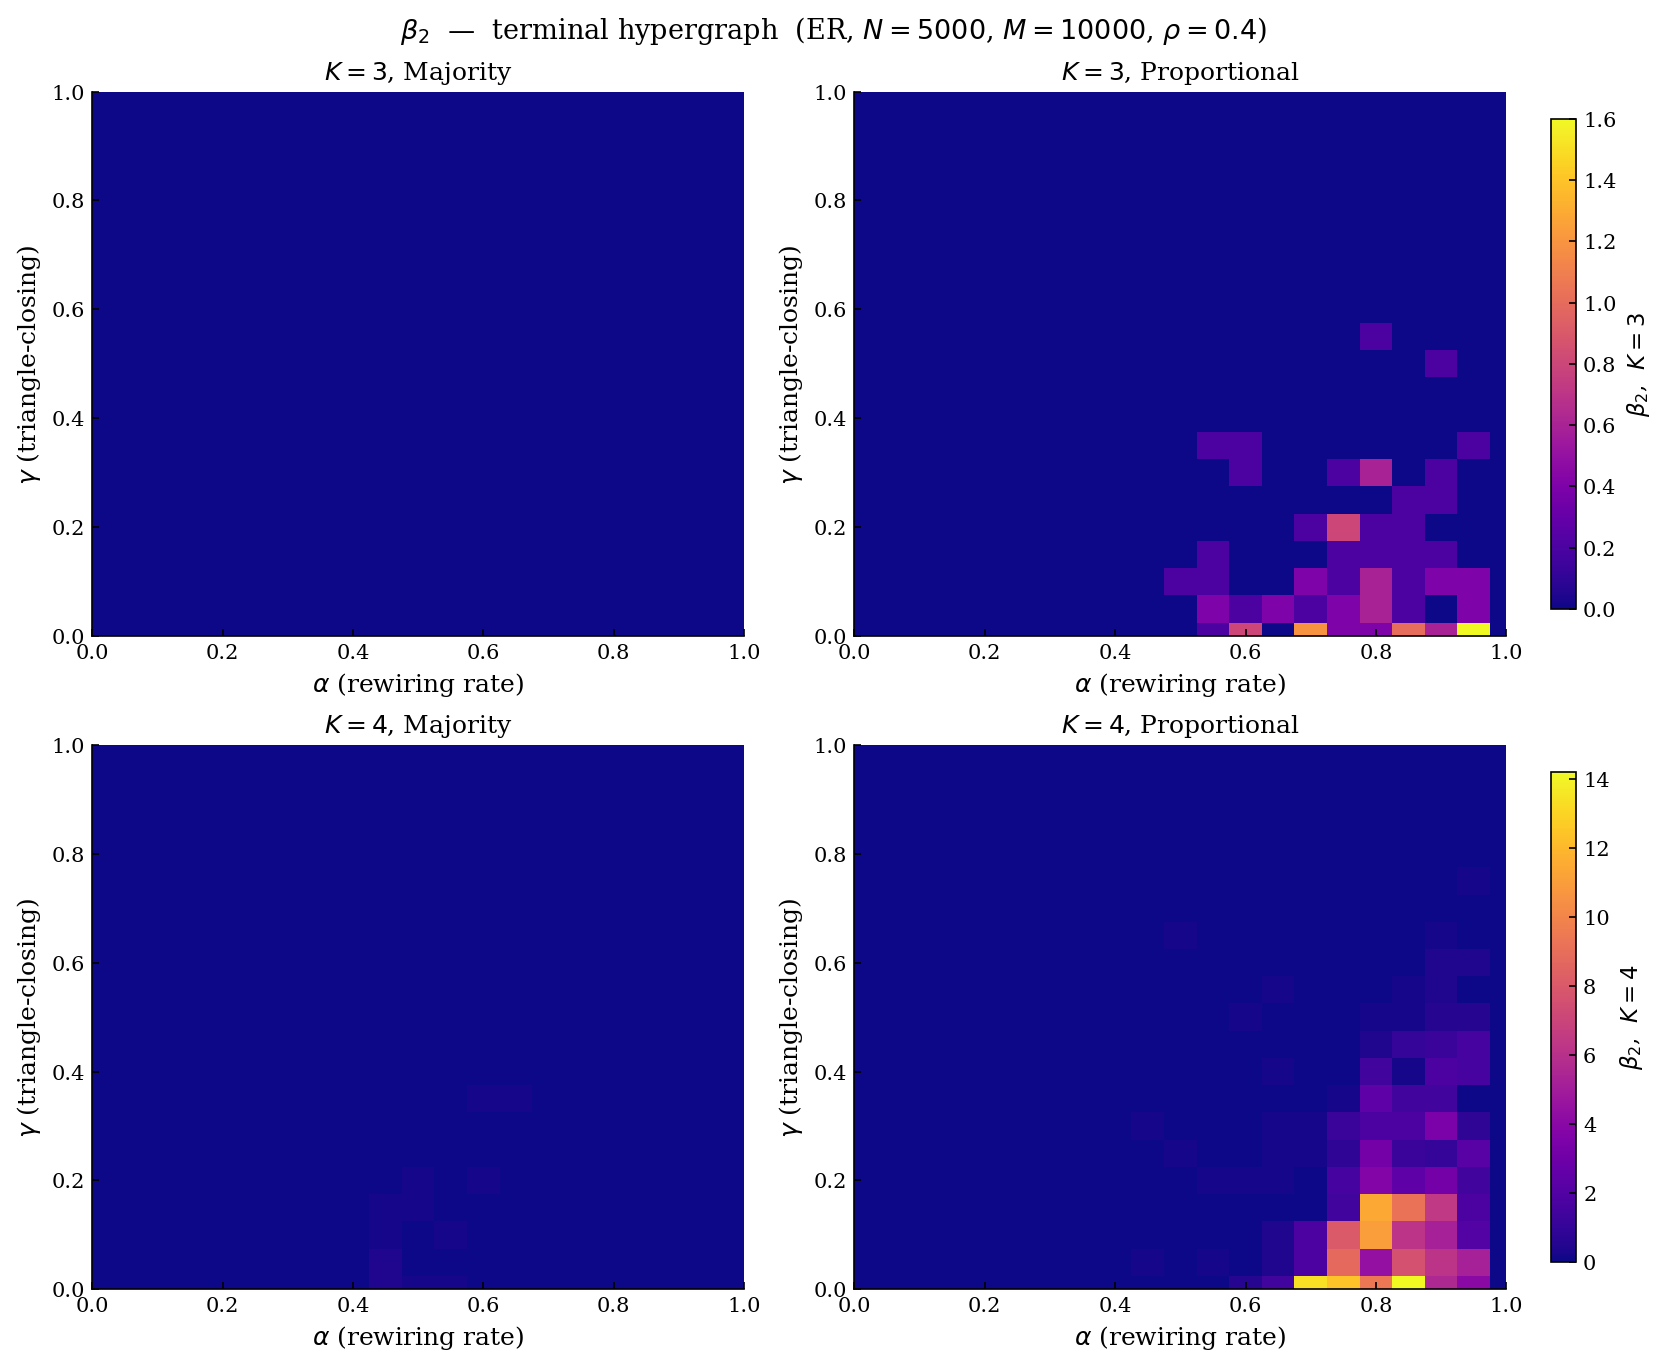

Saved: beta_2


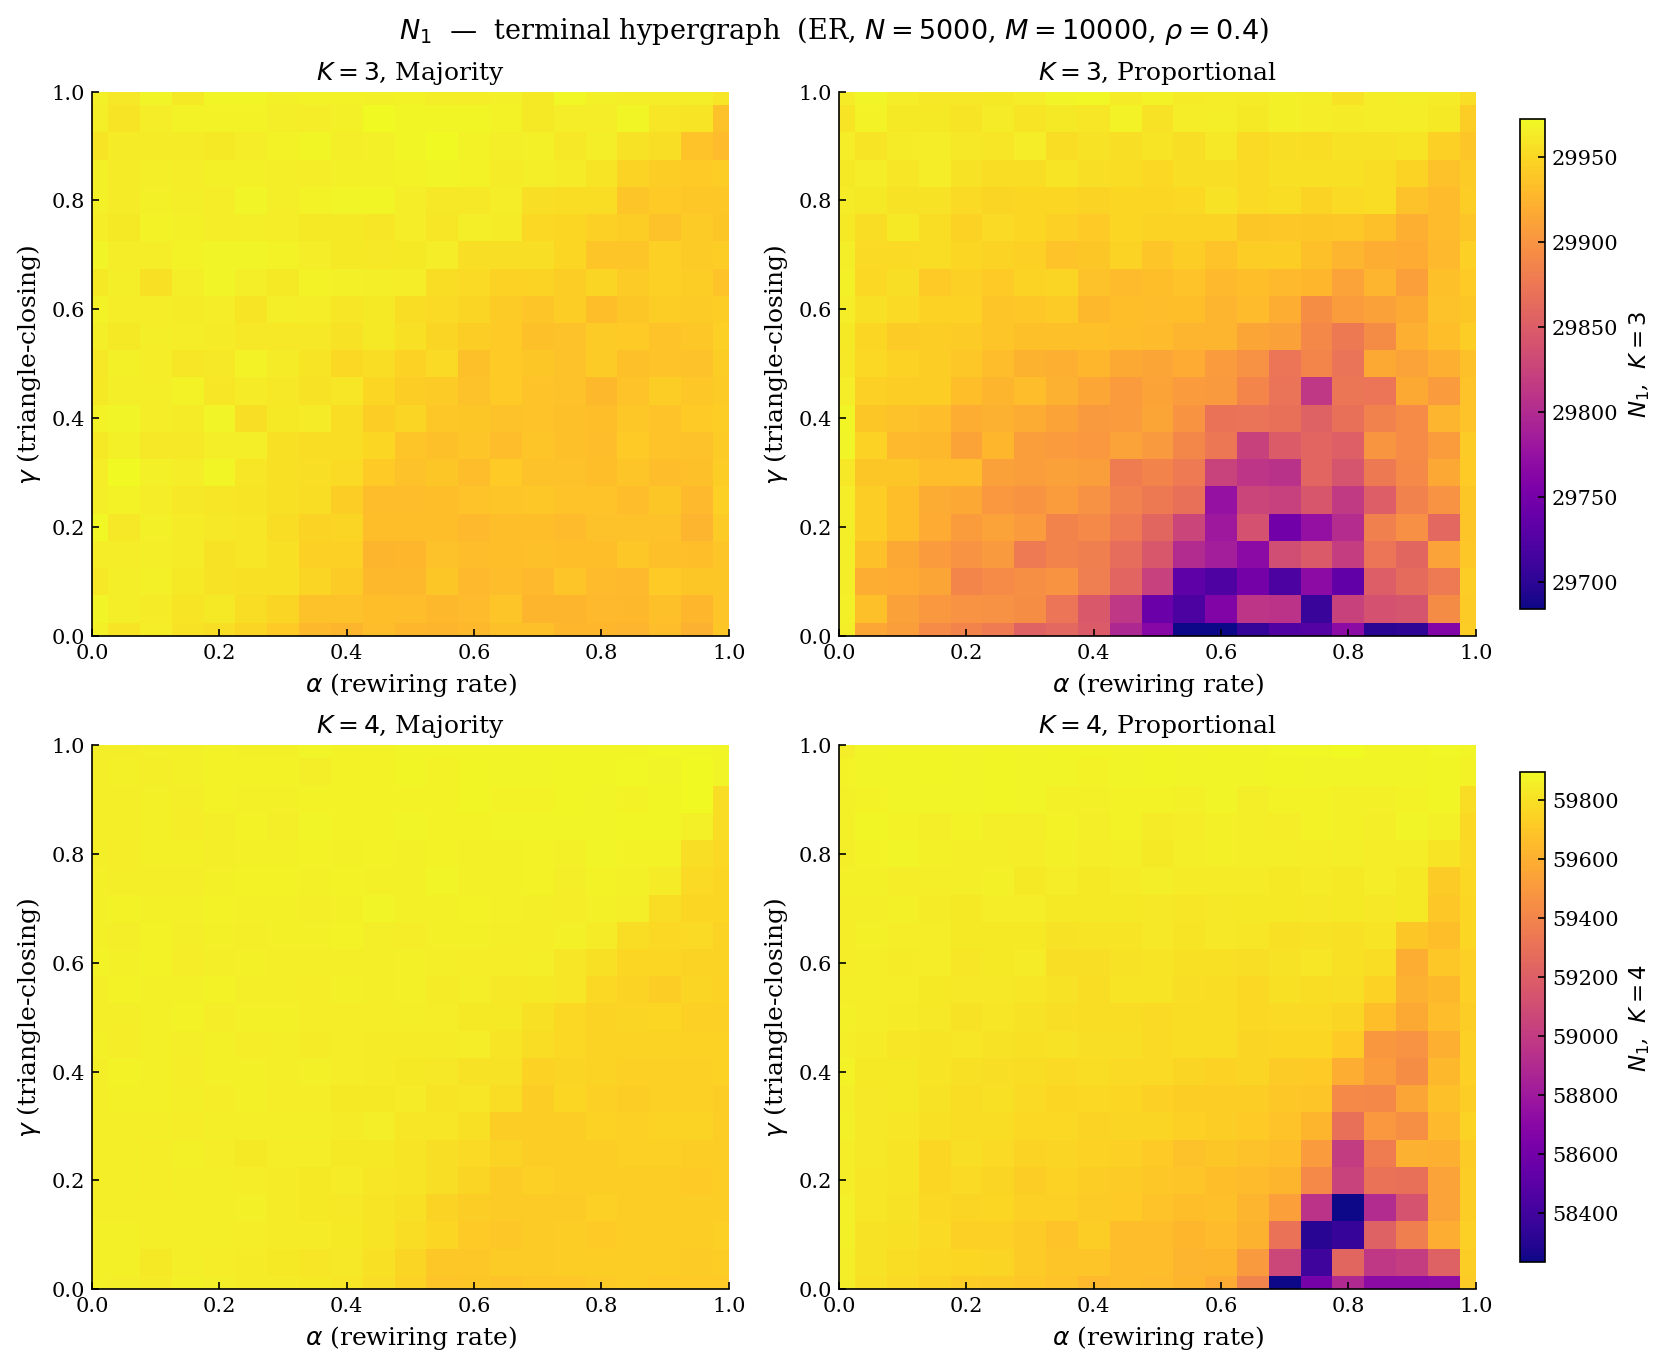

Saved: N_1


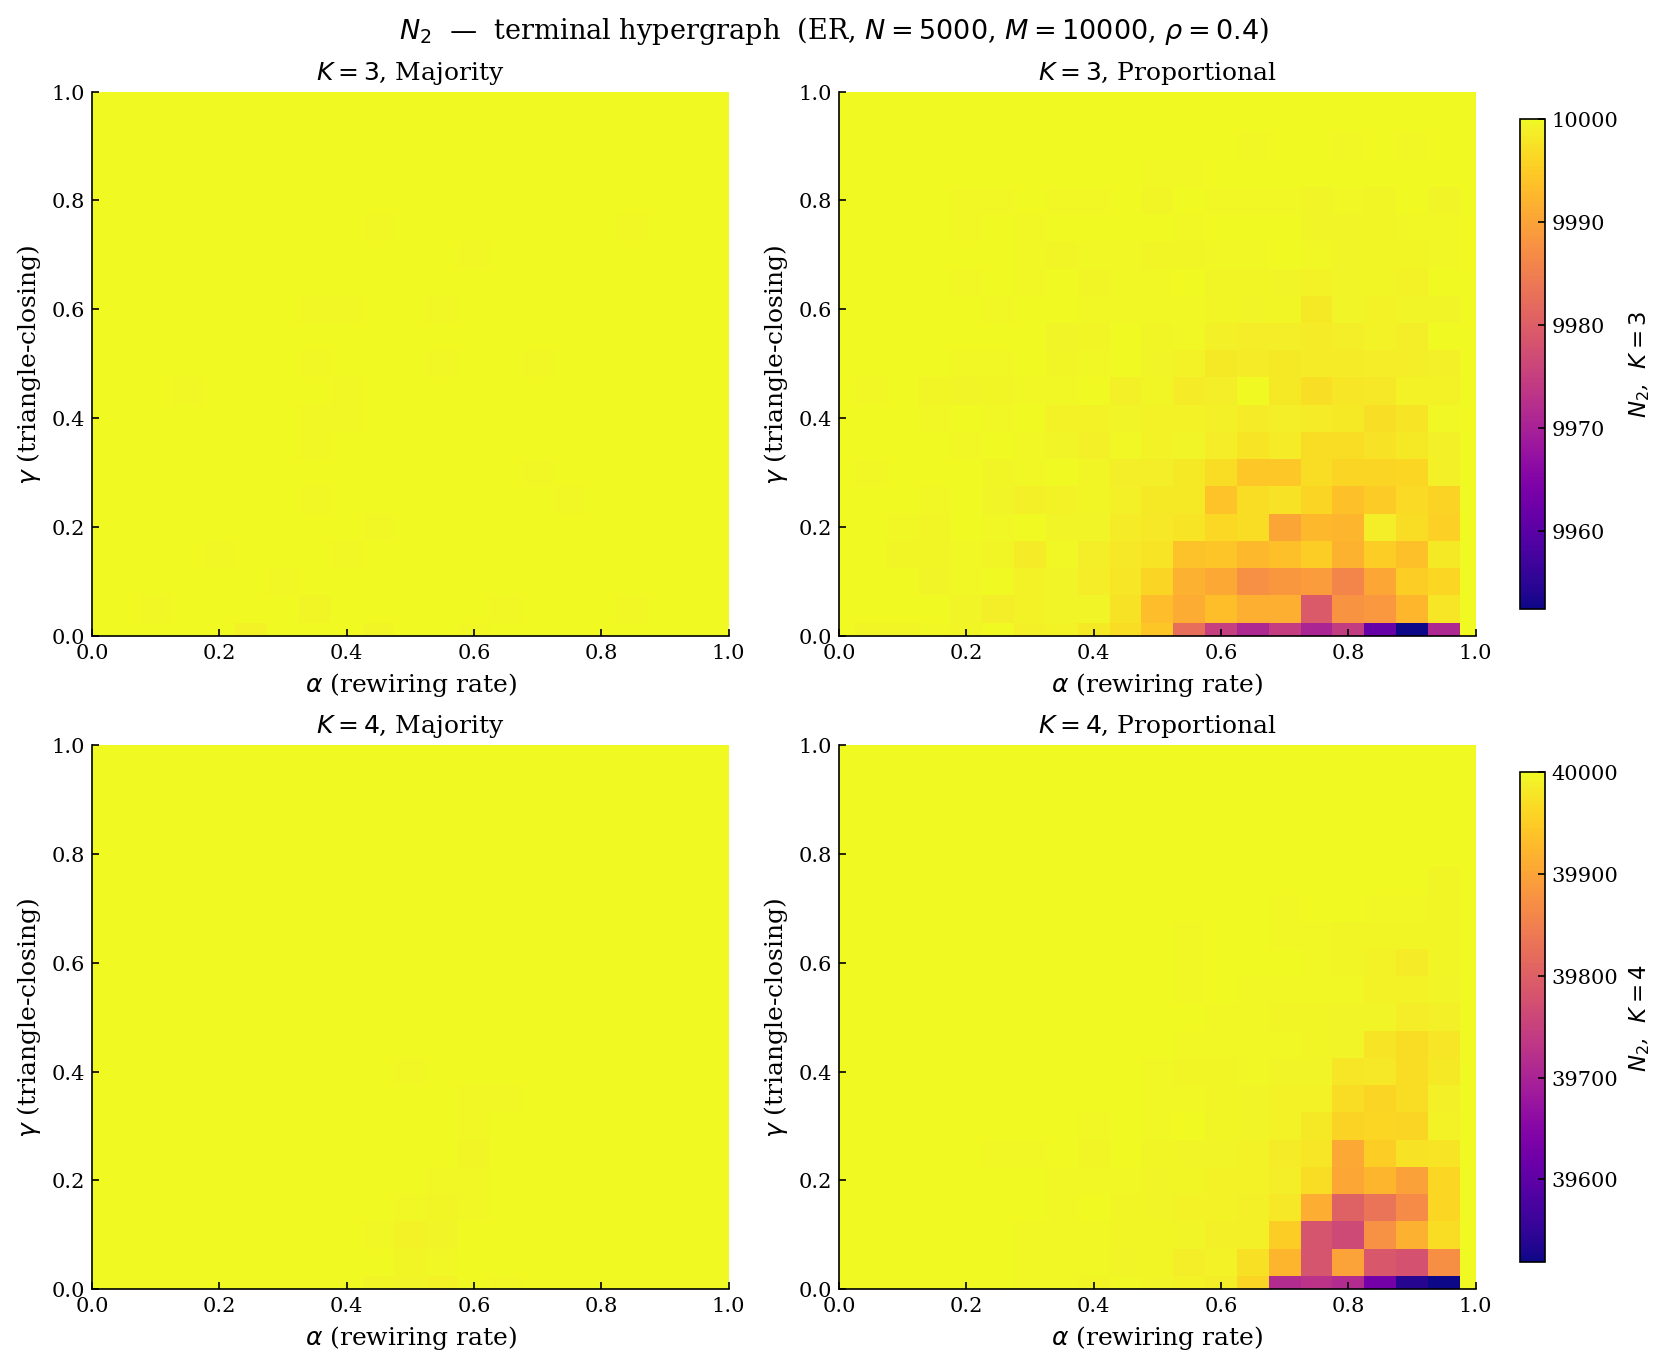

Saved: N_2


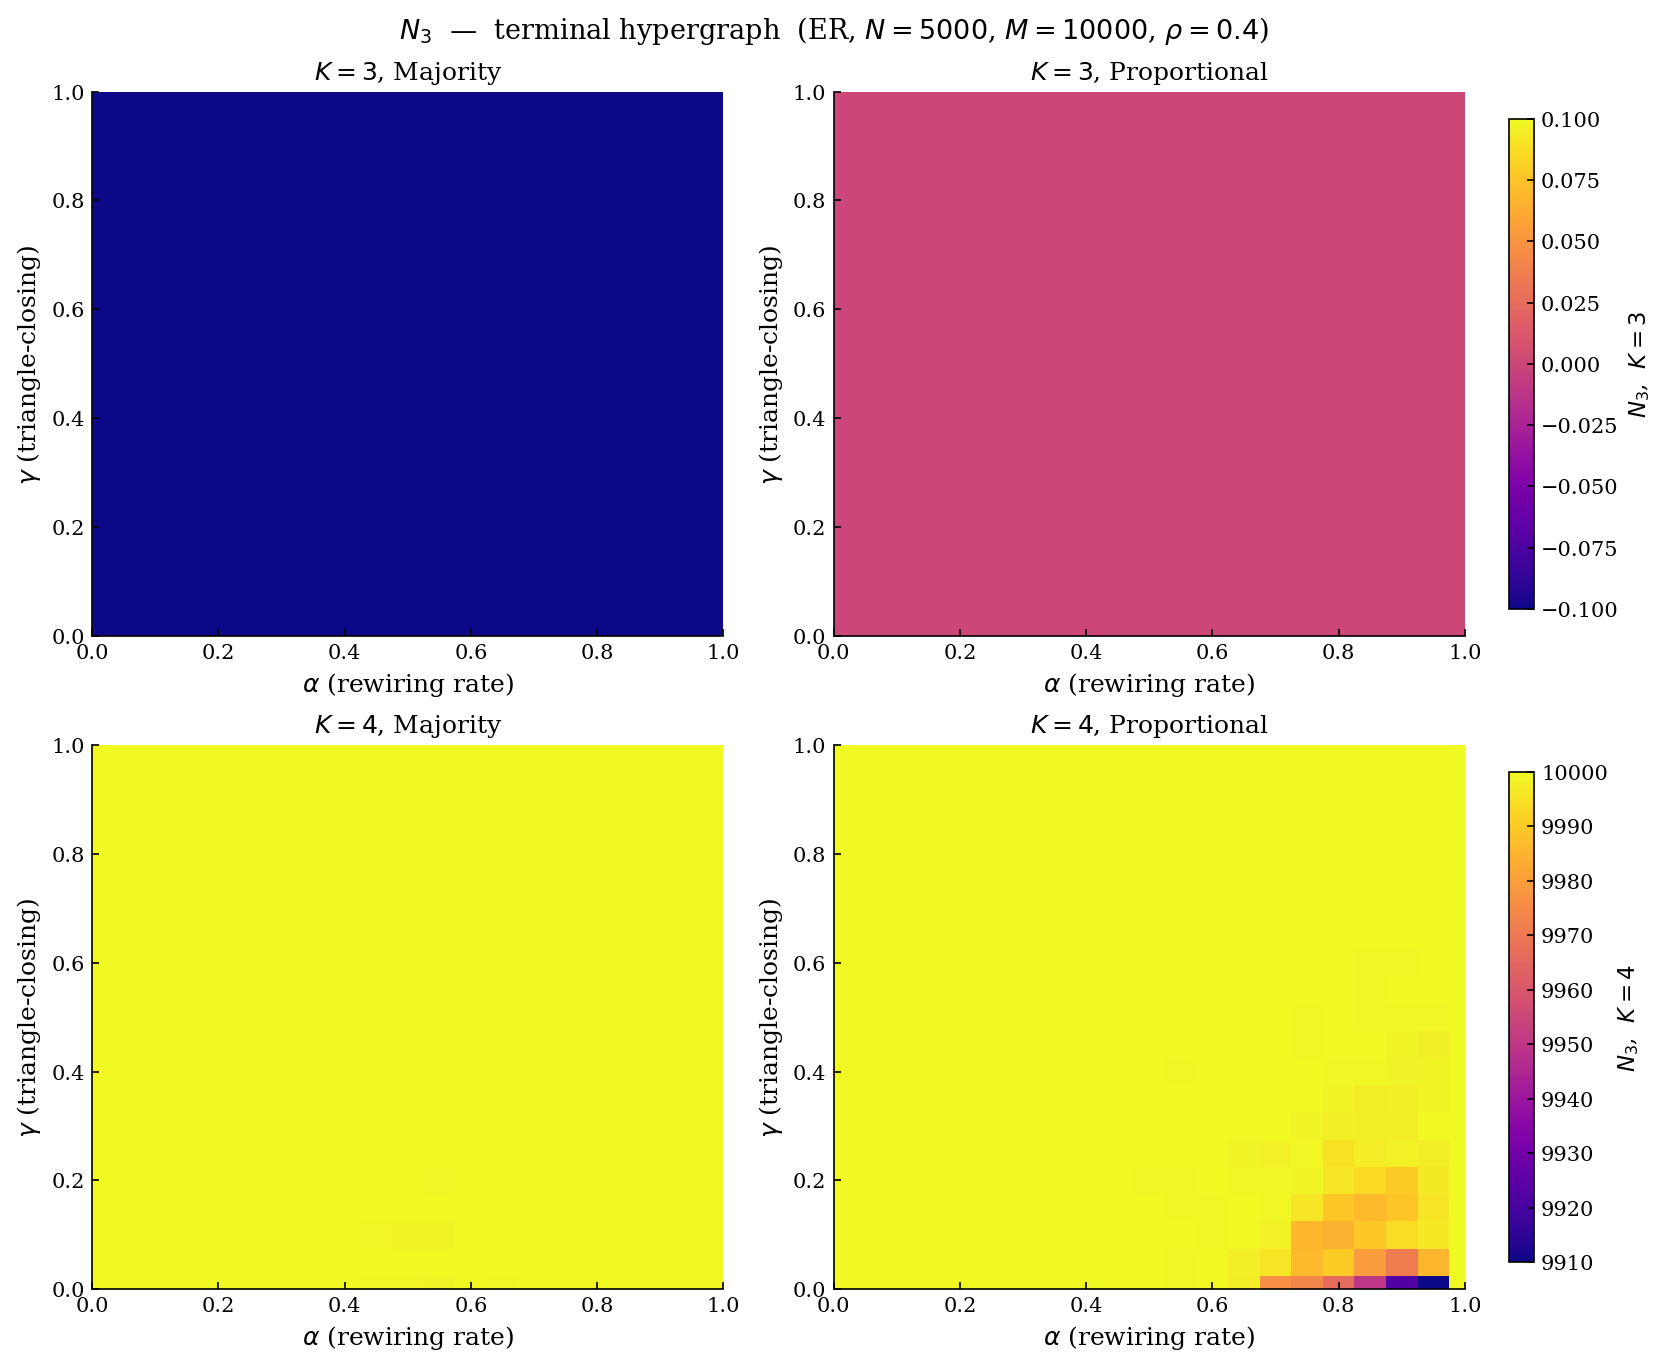

Saved: N_3


In [ ]:
# ── heatmap helper ────────────────────────────────────────────────────────────

def make_heatmap(ax, mat, title, cmap='plasma', vmin=None, vmax=None):
    finite = mat[np.isfinite(mat)]
    vmin   = finite.min() if vmin is None and len(finite) > 0 else vmin
    vmax   = finite.max() if vmax is None and len(finite) > 0 else vmax
    im = ax.pcolormesh(
        alphas, gammas, mat,
        cmap=cmap, shading='auto',
        norm=mcolors.Normalize(vmin=vmin, vmax=vmax),
    )
    ax.set_xlabel(r'$\alpha$ (rewiring rate)')
    ax.set_ylabel(r'$\gamma$ (triangle-closing)')
    ax.set_title(title, pad=6)
    ax.set_xlim(alphas[0], alphas[-1])
    ax.set_ylim(gammas[0], gammas[-1])
    return im

# ── generate one 2×2 figure per quantity ─────────────────────────────────────

quantity_keys = list(next(iter(next(iter(derived.values())).values())).keys())

for label in quantity_keys:
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)

    for row, k in enumerate(K_vals):
        # colour scale shared within this K row only
        k_vals_finite = np.concatenate([
            derived[k][v][label][np.isfinite(derived[k][v][label])].ravel()
            for v in voting_rules
        ])
        vmin = k_vals_finite.min() if len(k_vals_finite) > 0 else 0
        vmax = k_vals_finite.max() if len(k_vals_finite) > 0 else 1

        for col, v in enumerate(voting_rules):
            ax  = axes[row, col]
            mat = derived[k][v][label]
            im  = make_heatmap(ax, mat,
                               title=rf'$K={k}$, {v} Voting',
                               vmin=vmin, vmax=vmax)

        # one colourbar per row, anchored to the right panel of that row
        cbar = fig.colorbar(im, ax=axes[row, :], pad=0.02, shrink=0.9)
        cbar.set_label(rf'{label},  $K={k}$', fontsize=11)

    safe = label.replace('$','').replace('\\','').replace('{','').replace('}','').replace(' ','_')
    fig.suptitle(
        rf'{label}  —  terminal hypergraph  (ER, $N={N_nodes}$, $M={M}$, $\rho={rho}$)',
        fontsize=13,
    )
    fig.savefig(save_base + f'fig_TDA_{safe}.pdf', dpi=300, bbox_inches='tight')
    fig.savefig(save_base + f'fig_TDA_{safe}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {safe}')

## Simplicial Watts-Strogatz hypergraphs

Computing:   0%|          | 0/6600 [00:00<?, ?it/s]

Loading:   0%|          | 0/6600 [00:00<?, ?it/s]

Accumulating:   0%|          | 0/6600 [00:00<?, ?it/s]

Saved: /content/drive/My Drive/Colab Notebooks/Voter/Simplicial/proc/heatmap_simp_WS_K3_psub0_4.png


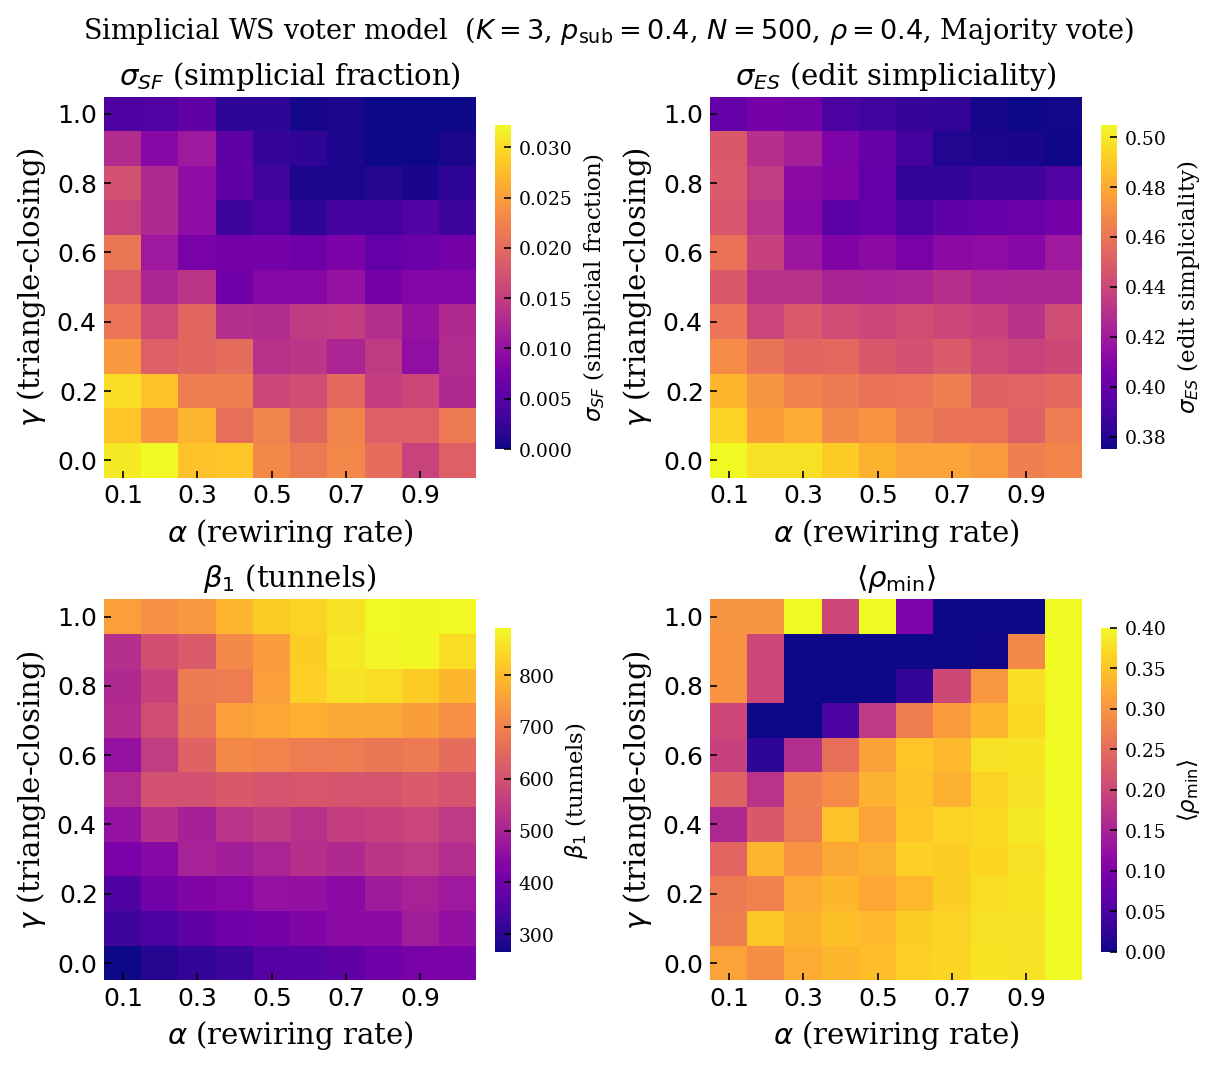

Saved: /content/drive/My Drive/Colab Notebooks/Voter/Simplicial/proc/heatmap_simp_WS_K3_psub0_5.png


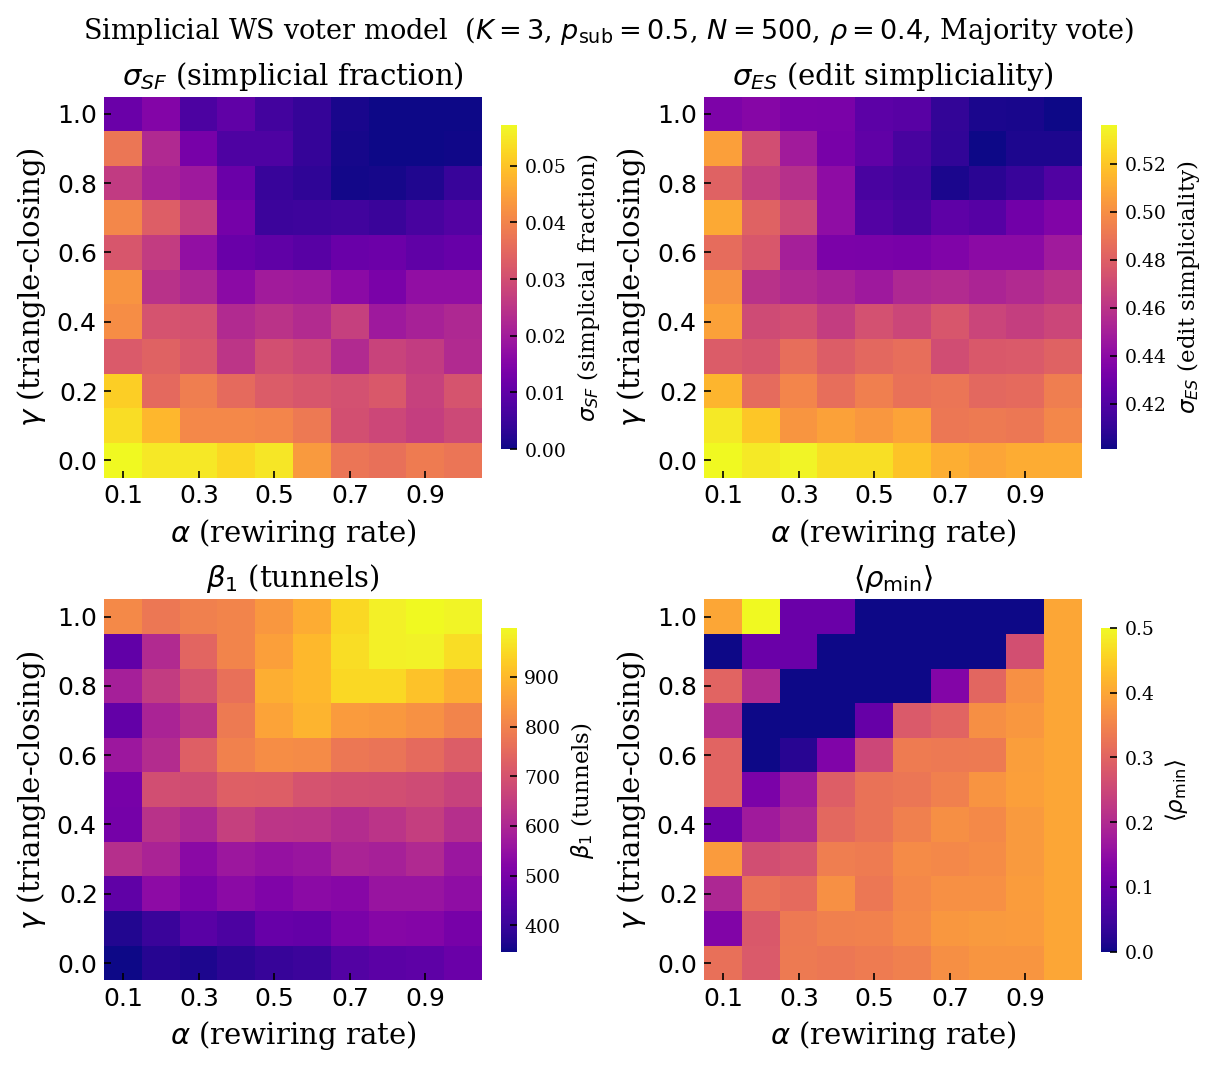

Saved: /content/drive/My Drive/Colab Notebooks/Voter/Simplicial/proc/heatmap_simp_WS_K3_psub0_6.png


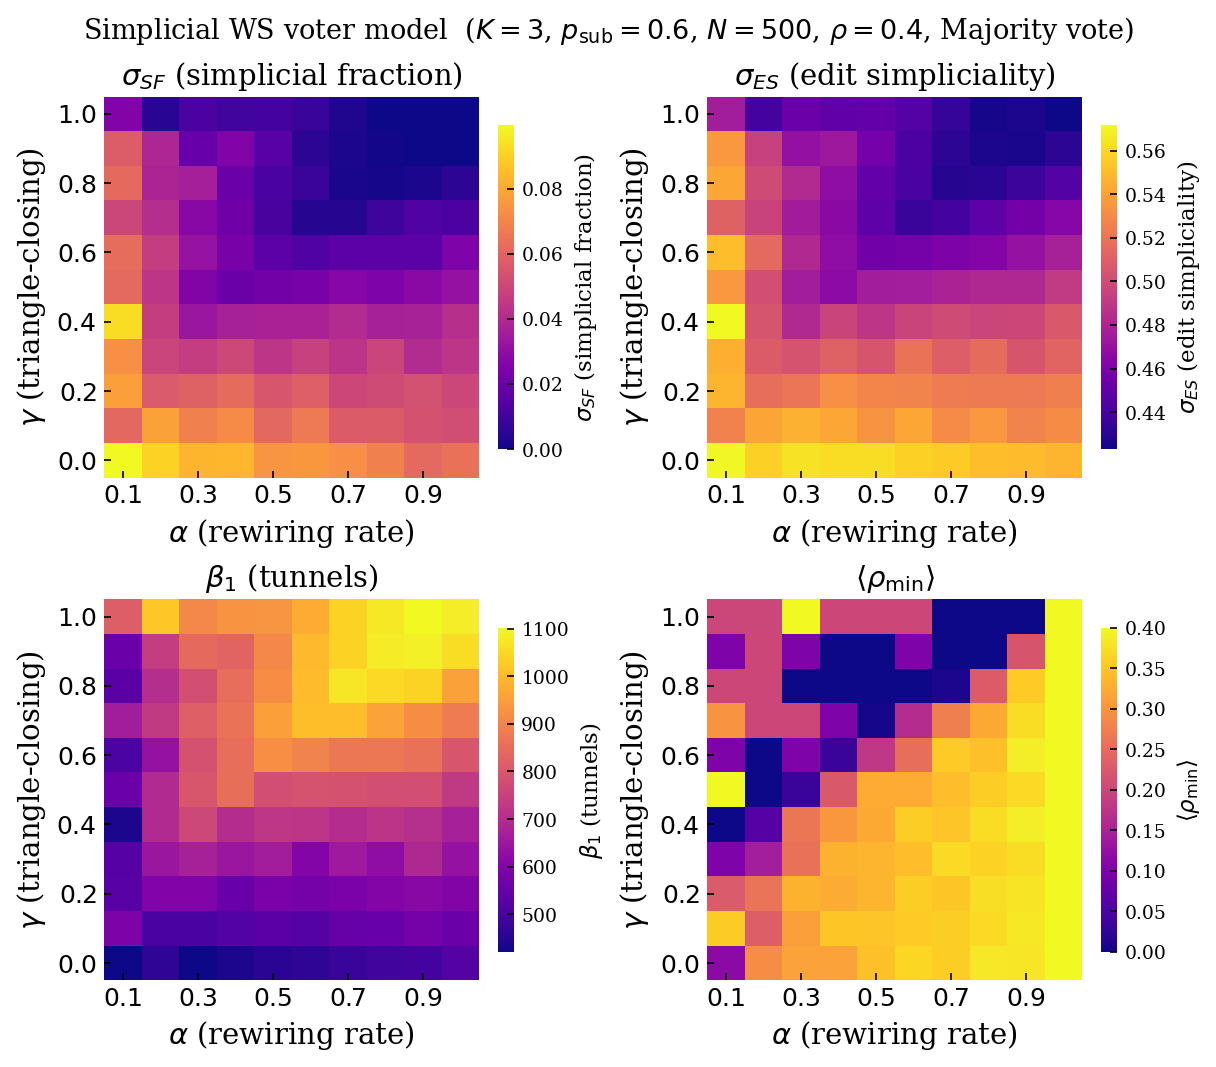

Saved: /content/drive/My Drive/Colab Notebooks/Voter/Simplicial/proc/heatmap_simp_WS_K4_psub0_4.png


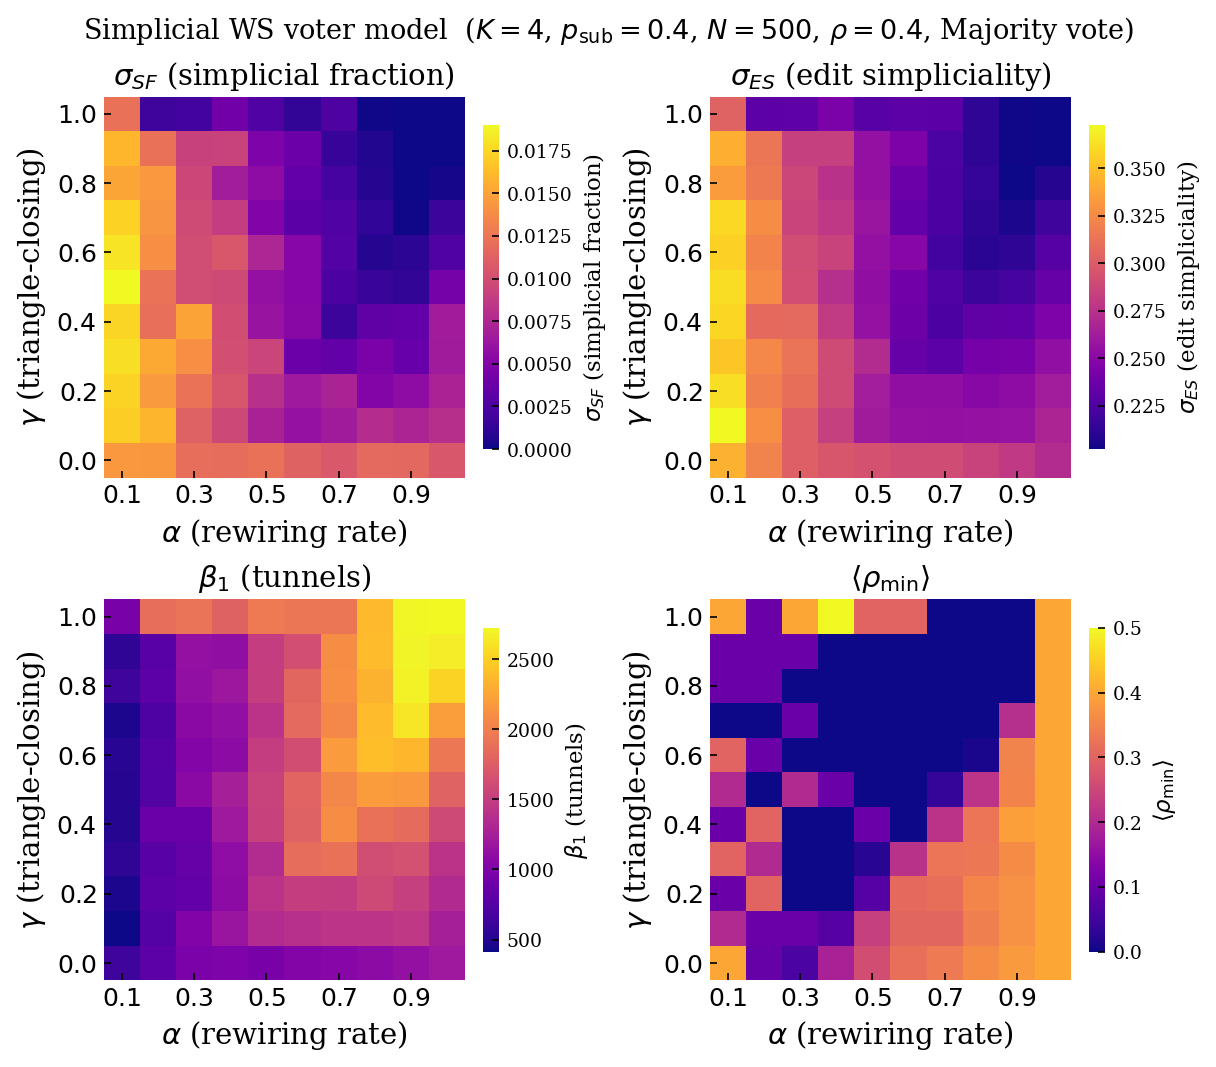

Saved: /content/drive/My Drive/Colab Notebooks/Voter/Simplicial/proc/heatmap_simp_WS_K4_psub0_5.png


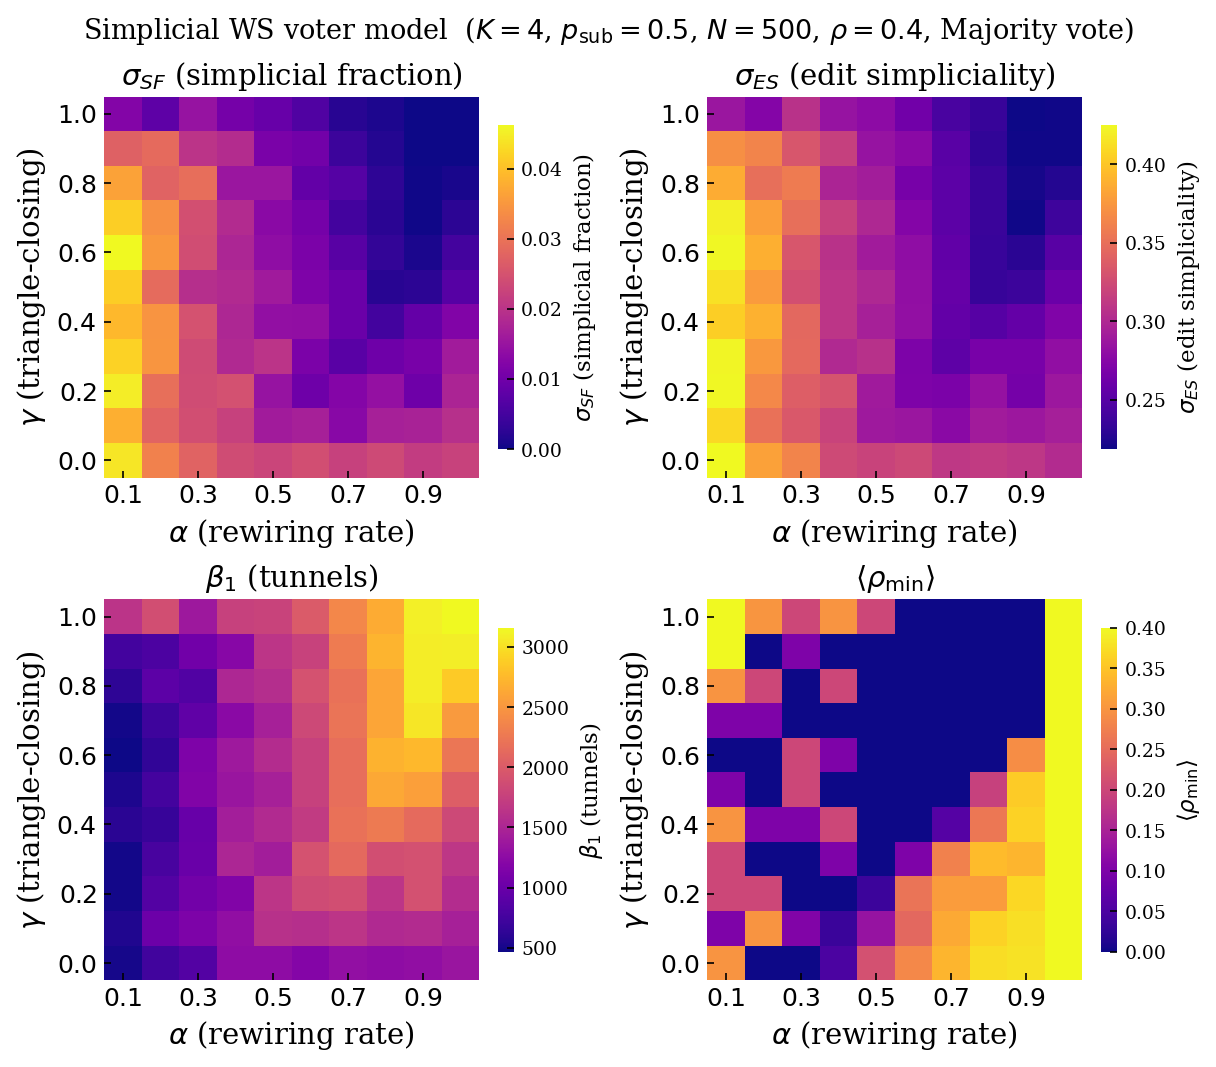

Saved: /content/drive/My Drive/Colab Notebooks/Voter/Simplicial/proc/heatmap_simp_WS_K4_psub0_6.png


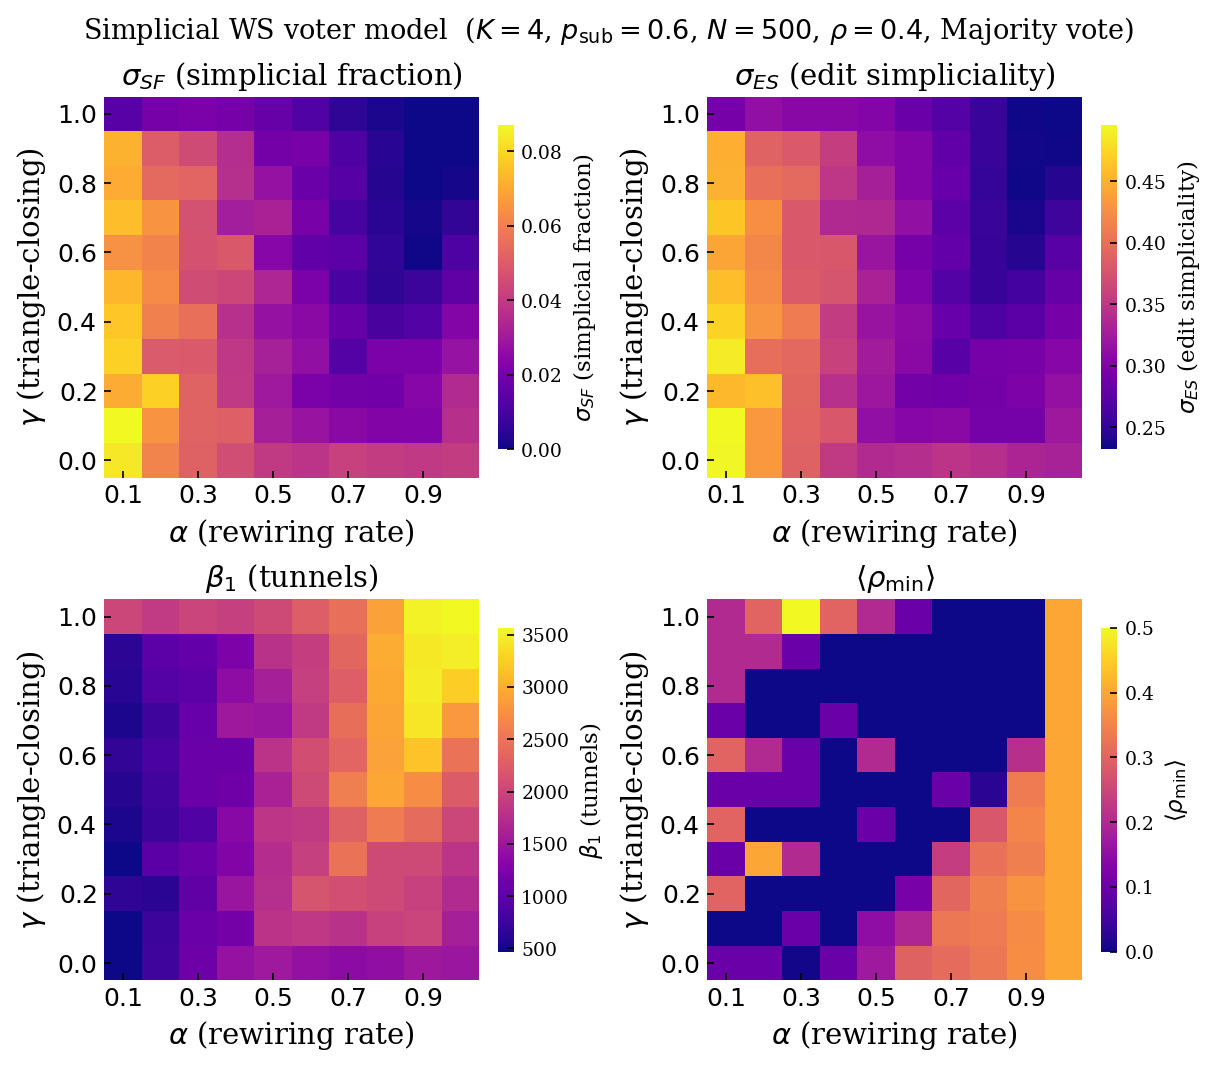

In [ ]:
# =============================================================================
# 1. CONFIGURATION
# =============================================================================
CMAP = 'plasma'

BASE_S  = '/content/drive/My Drive/Colab Notebooks/Voter/Simplicial/'
PROC_S  = os.path.join(BASE_S, 'proc')
os.makedirs(PROC_S, exist_ok=True)

n        = 500
K_vals   = [3, 4]
rho      = 0.4
alphas   = np.linspace(0, 1, 11)[1:]   # 10 values: 0.1 … 1.0
gammas   = np.linspace(0, 1, 11)       # 11 values: 0.0 … 1.0
voting   = 'Majority'
iterations = range(1, 11)
P_SUBS = [0.4, 0.5, 0.6]
na, ng   = len(alphas), len(gammas)

TICK_A   = np.arange(0, na, 2)
TICK_G   = np.arange(0, ng, 2)
XLABELS  = [f'${alphas[i]:.1f}$' for i in TICK_A]
YLABELS  = [f'${gammas[i]:.1f}$' for i in TICK_G]

fields   = ['b0', 'b1', 'b2', 'euler', 'N0', 'N1', 'N2', 'N3', 'sf', 'es', 'proportion']

# =============================================================================
# 2. FILENAME HELPERS — psub added to both functions
# =============================================================================

def raw_fname(k, psub, alpha, gamma, it):
    return os.path.join(BASE_S,
        f'WS_Simplicial_{n}_{k}_'
        f'{str(rho).replace(".","_")}_'
        f'{str(alpha).replace(".","_")}_'
        f'{str(gamma).replace(".","_")}_'
        f'{str(psub).replace(".","_")}_'
        f'{voting}_{it}.pkl')

def proc_fname(k, psub, ai, gi, it):
    return os.path.join(PROC_S,
        f'proc_{n}_{k}_psub{str(psub).replace(".","_")}_'
        f'a{ai}_g{gi}_it{it}.pkl.gz')


# =============================================================================
# 3. ACCUMULATORS — keyed by (k, psub)
# =============================================================================

sums   = {(k, p): {fld: np.zeros((ng, na)) for fld in fields}
          for k in K_vals for p in P_SUBS}
counts = {(k, p): np.zeros((ng, na))
          for k in K_vals for p in P_SUBS}


# =============================================================================
# 4. JOB LIST — psub added as second element
# =============================================================================

all_jobs = [
    (k, p, ai, gi, it)
    for k  in K_vals
    for p  in P_SUBS
    for ai in range(na)
    for gi in range(ng)
    for it in iterations
]


# =============================================================================
# 5. COMPUTE — psub threaded through
# =============================================================================

def compute_and_save(k, psub, ai, gi, it):
    pfname = proc_fname(k, psub, ai, gi, it)
    if os.path.isfile(pfname):
        return 'exists'
    rpath = raw_fname(k, psub, alphas[ai], gammas[gi], it)
    if not os.path.isfile(rpath):
        return 'missing'
    try:
        with gzip.open(rpath, 'rb') as f:
            data = pickle.load(f)
        proportion = float(data[0])
        H          = data[3]
        tda        = ComputeHGResults(H)
        cnts       = tda[4] if tda[4] is not None else []
        sf         = float(Get_Simpliciality_SF(H, minDim=2, maxDim=np.inf)[0])
        es         = float(Get_Simpliciality_ES(H, minDim=2, maxDim=np.inf))
        out = {
            'proportion': proportion,
            'b0': tda[0], 'b1': tda[1], 'b2': tda[2], 'euler': tda[3],
            'N0': cnts[0] if len(cnts) > 0 else 0,
            'N1': cnts[1] if len(cnts) > 1 else 0,
            'N2': cnts[2] if len(cnts) > 2 else 0,
            'N3': cnts[3] if len(cnts) > 3 else 0,
            'sf': sf,
            'es': es
        }
        with gzip.open(pfname, 'wb') as f:
            pickle.dump(out, f)
        return 'done'
    except Exception as e:
        return f'error: {e}'

Parallel(n_jobs=-1, backend='loky')(
    delayed(compute_and_save)(k, p, ai, gi, it)
    for k, p, ai, gi, it in tqdm(all_jobs, desc='Computing')
)


# =============================================================================
# 6. LOAD — psub in signature and return tuple
# =============================================================================

def load_one(k, psub, ai, gi, it):
    pfname = proc_fname(k, psub, ai, gi, it)
    if not os.path.isfile(pfname):
        return None
    try:
        with gzip.open(pfname, 'rb') as f:
            res = pickle.load(f)
        return (k, psub, ai, gi, res)
    except Exception:
        return None

loaded = Parallel(n_jobs=-1, backend='loky')(
    delayed(load_one)(k, p, ai, gi, it)
    for k, p, ai, gi, it in tqdm(all_jobs, desc='Loading')
)

for out in tqdm(loaded, desc='Accumulating'):
    if out is None:
        continue
    k, psub, ai, gi, res = out
    for fld in fields:
        sums[(k, psub)][fld][gi, ai] += res[fld]
    counts[(k, psub)][gi, ai] += 1


# =============================================================================
# 7. DERIVED QUANTITIES — keyed by (k, psub)
# =============================================================================

def smean(k, psub, fld):
    c = counts[(k, psub)]
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(c > 0, sums[(k, psub)][fld] / c, np.nan)

derived = {}
for k in K_vals:
    for psub in P_SUBS:
        b0  = smean(k, psub, 'b0');  b1  = smean(k, psub, 'b1')
        b2  = smean(k, psub, 'b2');  N0  = smean(k, psub, 'N0')
        N1  = smean(k, psub, 'N1');  N2  = smean(k, psub, 'N2')
        N3  = smean(k, psub, 'N3');  sf  = smean(k, psub, 'sf')
        prop = smean(k, psub, 'proportion'); es = smean(k, psub, 'es')
        with np.errstate(invalid='ignore', divide='ignore'):
            CR1   = N1 - N0 + b0
            CR1b1 = CR1 - b1
            g1    = np.where(N2 > 0, CR1b1 / N2, np.nan)
            minority = np.minimum(prop, 1.0 - prop)
        derived[(k, psub)] = {
            r'$\sigma_{SF}$ (simplicial fraction)':                  sf,
            r'$\sigma_{ES}$ (edit simpliciality)':                  es,
            r'$\beta_1$ (tunnels)':                      b1,
            r'$\langle\rho_{\min}\rangle$':   minority,
        }

# =============================================================================
# 8. PLOT — iterate over (k, psub) pairs
# =============================================================================
for k in K_vals:
    for psub in P_SUBS:
        plot_simplicial_heatmaps(n, rho, derived, CMAP, XLABELS, YLABELS, TICK_A, TICK_G,
                                 k=k, psub=psub,
            save_path=os.path.join(PROC_S,f'heatmap_simp_WS_K{k}_psub{str(psub).replace(".","_")}.png'))